# 1. Persiapan Environment dan Library
Bagian ini berfungsi untuk mengimpor semua library yang diperlukan untuk manipulasi data, visualisasi, NLP (Natural Language Processing), dan pemodelan machine learning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import string
import gc
import torch
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from gensim.models import Word2Vec
import gensim.downloader as api
from transformers import BertTokenizer, BertModel
from tqdm import tqdm

# Resources
nltk.download('stopwords')
nltk.download('punkt')

# ==================================================================
# 1. CENTRALIZED CONFIGURATION
# ==================================================================
CONFIG = {
    'RANDOM_STATE': 42,
    'TEST_SIZE': 0.2,
    'MAX_FEATURES': 2000,
    'MAX_LEN': 64,
    'BATCH_SIZE': 8,
    'W2V_SIZE': 100,
    'W2V_WINDOW': 5,
    'BERT_SUBSET': 500
}

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RESULTS = [] # Ini akan menampung hasil final dari sel individual

print(f"Environment Ready. Device: {DEVICE}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Environment Ready. Device: cpu


# 2. Loading Dataset
Sel ini memuat data Wine Reviews. Jika file CSV lokal tidak ditemukan, sistem akan membuat dataset contoh kecil untuk memastikan kode tetap dapat berjalan.

In [ ]:
# Simulasi load data (Ganti path sesuai lokasi file Anda)
try:
    # Memperbaiki typo index_index menjadi index_col
    df = pd.read_csv('winemag-data-130k-v2.csv', index_col=0)
except Exception as e:
    # Jika file tidak ditemukan, gunakan subset kecil untuk demonstrasi
    print(f"File tidak ditemukan ({e}), menggunakan dataset contoh...")
    # Gunakan np.nan sebagai pengganti NaN
    data = {
        'country': ['Italy', 'Portugal', 'US', 'US', 'US', 'Spain', 'Italy', 'France', 'Germany', 'France'],
        'description': ["Aromas of prune, blackcurrant, toast and Oak.", "This is ripe and full-bodied.", "Tart and snappy, the flavors of lime.", "Pineapple rind, lemon pith and orange blossom.", "Much like the regular bottling, this comes across as rather rough.", "Blackberry and raspberry aromas.", "Here's a bright, fun sparkling wine.", "This dry and restrained wine.", "Savory dried thyme notes.", "This has great weight of fruit."],
        'points': [87, 87, 87, 87, 87, 87, 87, 87, 87, 87],
        'price': [np.nan, 15.0, 14.0, 13.0, 65.0, 15.0, 16.0, 24.0, 12.0, 27.0],
        'variety': ['White Blend', 'Portuguese Red', 'Pinot Gris', 'Riesling', 'Pinot Noir', 'Tempranillo-Merlot', 'Frappato', 'Gewürztraminer', 'Gewürztraminer', 'Pinot Gris'],
        'winery': ['Nicosia', 'Quinta dos Avidagos', 'Rainstorm', 'St. Julian', 'Sweet Cheeks', 'Tandem', 'Terre di Giurfo', 'Trimbach', 'Heinz Eifel', 'Jean-Baptiste Adam']
    }
    df = pd.DataFrame(data)

display(df.head())
print(f"Shape: {df.shape}")

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


Shape: (129971, 13)


# 3. Statistik Deskriptif
Menampilkan ringkasan statistik untuk memahami tipe data, rentang nilai, dan jumlah nilai unik pada setiap atribut utama.

In [ ]:
# Statistik Deskriptif seperti Laporan
stats_table = pd.DataFrame({
    'Atribut': ['points', 'price', 'country', 'variety', 'winery'],
    'Tipe Data': [df['points'].dtype, df['price'].dtype, 'object', 'object', 'object'],
    'Nilai Minimum': [df['points'].min(), df['price'].min(), '-', '-', '-'],
    'Nilai Maksimum': [df['points'].max(), df['price'].max(), '-', '-', '-'],
    'Rata-rata': [df['points'].mean(), df['price'].mean(), '-', '-', '-'],
    'Jumlah Unik': [df['points'].nunique(), df['price'].nunique(), df['country'].nunique(), df['variety'].nunique(), df['winery'].nunique()]
})
display(stats_table)

,Atribut,Tipe Data,Nilai Minimum,Nilai Maksimum,Rata-rata,Jumlah Unik
0,points,int64,80,100,88.447138,21
1,price,float64,4.0,3300.0,35.363389,390
2,country,object,-,-,-,43
3,variety,object,-,-,-,707
4,winery,object,-,-,-,16757


# 4. Analisis Missing Value
Berfungsi untuk mendeteksi data yang kosong pada setiap kolom dan memvisualisasikan persentasenya.

,Atribut,Jumlah Missing,Persentase
7,region_2,79460,61.136715
2,designation,37465,28.825661
9,taster_twitter_handle,31213,24.015357
8,taster_name,26244,20.192197
6,region_1,21247,16.347493
4,price,8996,6.921544
5,province,63,0.048472
0,country,63,0.048472
11,variety,1,0.000769
3,points,0,0.000000


/tmp/ipykernel_6138/1543093653.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Persentase', y='Atribut', data=missing_df, palette='Reds_r')


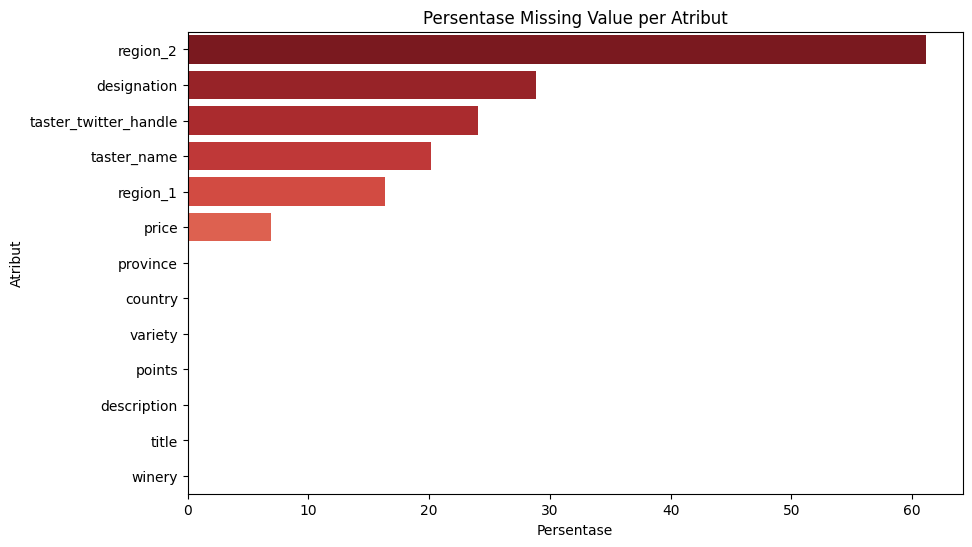

In [ ]:
missing = df.isnull().sum()
percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Atribut': missing.index,
    'Jumlah Missing': missing.values,
    'Persentase': percent.values
}).sort_values(by='Jumlah Missing', ascending=False)

display(missing_df)

# Visualisasi
plt.figure(figsize=(10, 6))
sns.barplot(x='Persentase', y='Atribut', data=missing_df, palette='Reds_r')
plt.title('Persentase Missing Value per Atribut')
plt.show()

# 5. Pelabelan Target (Quality Label)
Mengonversi skor numerik (`points`) menjadi kategori kualitas ('Low', 'Medium', 'High') untuk keperluan klasifikasi.

,Kategori,Jumlah Data,Persentase,Rentang
0,Medium,74376,57.225073,86-90
1,High,33635,25.878850,> 90
2,Low,21960,16.896077,<= 85


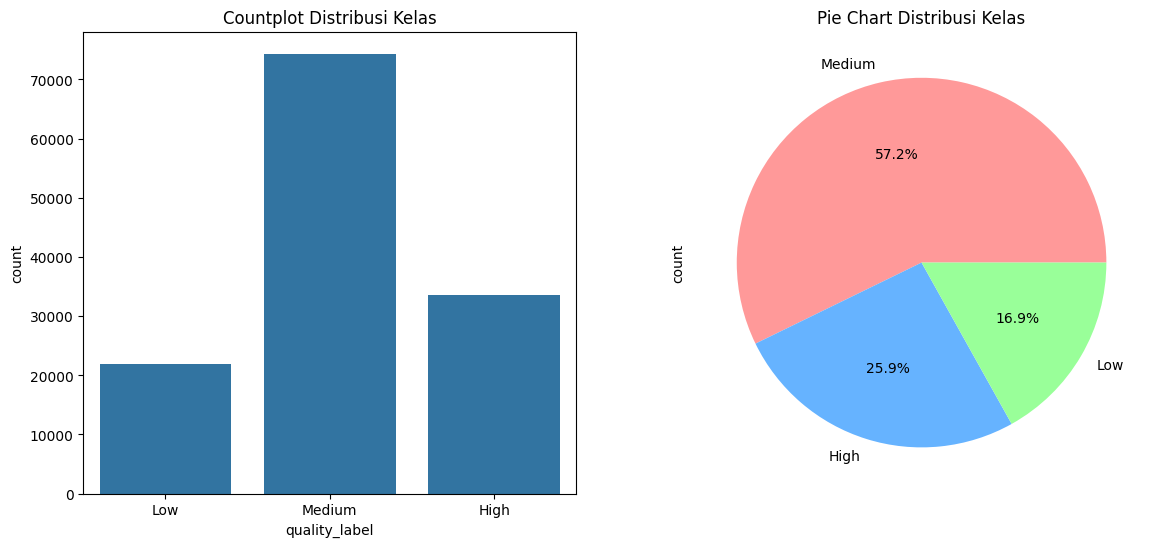

In [ ]:
def label_quality(p):
    if p <= 85: return 'Low'
    elif p <= 90: return 'Medium'
    else: return 'High'

df['quality_label'] = df['points'].apply(label_quality)

distribusi = df['quality_label'].value_counts().reset_index()
distribusi.columns = ['Kategori', 'Jumlah Data']
distribusi['Persentase'] = (distribusi['Jumlah Data'] / len(df)) * 100
distribusi['Rentang'] = ['86-90', '> 90', '<= 85'] # Contoh urutan sesuai data

display(distribusi)

# Visualisasi
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
sns.countplot(data=df, x='quality_label', ax=ax[0], order=['Low', 'Medium', 'High'])
ax[0].set_title('Countplot Distribusi Kelas')

df['quality_label'].value_counts().plot.pie(autopct='%1.1f%%', ax=ax[1], colors=['#ff9999','#66b3ff','#99ff99'])
ax[1].set_title('Pie Chart Distribusi Kelas')
plt.show()

# 6. Sampling Data
Mengambil 10.000 sampel data secara acak untuk mengoptimalkan kecepatan pemrosesan selama eksperimen.

In [ ]:
print("Before Selection & Sampling:")
display(df.head(2))

# Memilih kolom dan mengambil 10.000 sampel acak untuk efisiensi
selected_df = df[['description', 'quality_label']].sample(10000, random_state=42).reset_index(drop=True)

print(f"\nAfter Selection & Sampling (Total Data: {len(selected_df)}):")
display(selected_df.head(2))

Before Selection & Sampling:


,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery,quality_label
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia,Medium
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos,Medium



After Selection & Sampling (Total Data: 10000):


,description,quality_label
0,"Possibly a little sweet, this is a soft, easyg...",Low
1,"A soft, almost off dry wine that is full in th...",Low


# 7. Pembersihan Data Dasar
Menghapus nilai kosong pada deskripsi, menghilangkan data duplikat, dan memfilter teks yang terlalu pendek (di bawah 3 kata).

In [ ]:
# 1. Cek Missing Value pada fitur utama
missing_info = selected_df[['description', 'quality_label']].isnull().sum()

# 2. Cek & Hapus Duplikat
initial_count = len(selected_df)
duplicate_count = selected_df.duplicated().sum()
selected_df = selected_df.drop_duplicates().reset_index(drop=True)
final_count = len(selected_df)

# Tampilkan Tabel Duplikat
dup_summary = pd.DataFrame({
    'Jumlah Data Awal': [initial_count],
    'Jumlah Duplikat': [duplicate_count],
    'Jumlah Setelah Hapus': [final_count]
})
display(dup_summary)

# 3. Filtering: Hapus teks dengan jumlah kata <= 3
before_filter = len(selected_df)
selected_df = selected_df[selected_df['description'].apply(lambda x: len(str(x).split()) > 3)]
after_filter = len(selected_df)

# Tampilkan Tabel Filtering
filter_summary = pd.DataFrame({
    'Keterangan': ['Sebelum Filtering', 'Sesudah Filtering (Kata > 3)'],
    'Jumlah Data': [before_filter, after_filter]
})
display(filter_summary)

,Jumlah Data Awal,Jumlah Duplikat,Jumlah Setelah Hapus
0,10000,59,9941


,Keterangan,Jumlah Data
0,Sebelum Filtering,9941
1,Sesudah Filtering (Kata > 3),9941


# 8. Pipeline Text Preprocessing
Fungsi ini melakukan serangkaian pembersihan teks: mengubah ke huruf kecil, menghapus tanda baca/angka, menghapus *stopwords*, dan melakukan *stemming*.

In [ ]:
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # 7.1 Case Folding
    text = text.lower()
    # 7.2 Punctuation Removal
    text = text.translate(str.maketrans('', '', string.punctuation))
    # 7.3 Remove Number
    text = re.sub(r'\d+', '', text)
    # 7.4 Whitespace Removal
    text = " ".join(text.split())
    # 7.5 Stopword Removal
    words = text.split()
    words = [w for w in words if not w in stop_words]
    # 7.6 Stemming
    words = [ps.stem(w) for w in words]
    return " ".join(words)

# Demonstrasi bertahap pada subset kecil
sample_data = selected_df['description'].head(10).copy()
selected_df['final_text'] = selected_df['description'].apply(clean_text)

display(selected_df[['description', 'final_text']].head(10))

,description,final_text
0,"Possibly a little sweet, this is a soft, easyg...",possibl littl sweet soft easygo chardonnay mar...
1,"A soft, almost off dry wine that is full in th...",soft almost dri wine full mouth caramel spice ...
2,Generic white-fruit aromas of peach and apple ...,gener whitefruit aroma peach appl slightli pit...
3,This is the winery's best Nebula in years. Whi...,wineri best nebula year still littl soft sweet...
4,This is a very rich Pinot whose primary virtue...,rich pinot whose primari virtu fruit explod de...
5,"An unabashedly rich and luscious wine, this co...",unabashedli rich lusciou wine combin ripe fres...
6,"This opens with a pleasing toasty aroma, follo...",open pleas toasti aroma follow palat deft touc...
7,"Made with 100% Chardonnay, this creamy sparkle...",made chardonnay creami sparkler open aroma haw...
8,"Here's a good, everyday Cab if you're looking ...",here good everyday cab your look bargain dri t...
9,"Made from low-yielding, 70-year-old vines, thi...",made lowyield yearold vine dens wine almostdar...


# 9. Representasi Teks: TF-IDF
Mengubah teks mentah menjadi representasi numerik menggunakan metode Term Frequency-Inverse Document Frequency.

In [ ]:
# 7.1 - 7.6 Demonstrasi Bertahap Preprocessing (Before-After)
sample_texts = selected_df['description'].head(10).tolist()

def get_stepwise_comparison(texts):
    c0 = texts
    c1 = [t.lower() for t in c0]
    c2 = [t.translate(str.maketrans('', '', string.punctuation)) for t in c1]
    c3 = [re.sub(r'\d+', '', t) for t in c2]
    c4 = [" ".join(t.split()) for t in c3]
    c5 = [" ".join([w for w in t.split() if w not in stop_words]) for t in c4]
    c6 = [" ".join([ps.stem(w) for w in t.split()]) for t in c5]
    return [c0, c1, c2, c3, c4, c5, c6]

stages = ['Original', 'Case Folding', 'Punctuation Removal', 'Remove Number', 'Whitespace Removal', 'Stopword Removal', 'Stemming (Final Text)']
results = get_stepwise_comparison(sample_texts)

for i in range(len(stages)-1):
    print(f"\n>>> TAHAP PREPROCESSING: {stages[i+1]}")
    comparison_df = pd.DataFrame({'Before': results[i], 'After': results[i+1]})
    display(comparison_df.head(10))

selected_df['final_text'] = selected_df['description'].apply(clean_text)


>>> TAHAP PREPROCESSING: Case Folding


,Before,After
0,"Possibly a little sweet, this is a soft, easyg...","possibly a little sweet, this is a soft, easyg..."
1,"A soft, almost off dry wine that is full in th...","a soft, almost off dry wine that is full in th..."
2,Generic white-fruit aromas of peach and apple ...,generic white-fruit aromas of peach and apple ...
3,This is the winery's best Nebula in years. Whi...,this is the winery's best nebula in years. whi...
4,This is a very rich Pinot whose primary virtue...,this is a very rich pinot whose primary virtue...
5,"An unabashedly rich and luscious wine, this co...","an unabashedly rich and luscious wine, this co..."
6,"This opens with a pleasing toasty aroma, follo...","this opens with a pleasing toasty aroma, follo..."
7,"Made with 100% Chardonnay, this creamy sparkle...","made with 100% chardonnay, this creamy sparkle..."
8,"Here's a good, everyday Cab if you're looking ...","here's a good, everyday cab if you're looking ..."
9,"Made from low-yielding, 70-year-old vines, thi...","made from low-yielding, 70-year-old vines, thi..."



>>> TAHAP PREPROCESSING: Punctuation Removal


,Before,After
0,"possibly a little sweet, this is a soft, easyg...",possibly a little sweet this is a soft easygoi...
1,"a soft, almost off dry wine that is full in th...",a soft almost off dry wine that is full in the...
2,generic white-fruit aromas of peach and apple ...,generic whitefruit aromas of peach and apple a...
3,this is the winery's best nebula in years. whi...,this is the winerys best nebula in years while...
4,this is a very rich pinot whose primary virtue...,this is a very rich pinot whose primary virtue...
5,"an unabashedly rich and luscious wine, this co...",an unabashedly rich and luscious wine this com...
6,"this opens with a pleasing toasty aroma, follo...",this opens with a pleasing toasty aroma follow...
7,"made with 100% chardonnay, this creamy sparkle...",made with 100 chardonnay this creamy sparkler ...
8,"here's a good, everyday cab if you're looking ...",heres a good everyday cab if youre looking for...
9,"made from low-yielding, 70-year-old vines, thi...",made from lowyielding 70yearold vines this is ...



>>> TAHAP PREPROCESSING: Remove Number


...

,Before,After
0,possibly a little sweet this is a soft easygoi...,possibly a little sweet this is a soft easygoi...
1,a soft almost off dry wine that is full in the...,a soft almost off dry wine that is full in the...
2,generic whitefruit aromas of peach and apple a...,generic whitefruit aromas of peach and apple a...
3,this is the winerys best nebula in years while...,this is the winerys best nebula in years while...
4,this is a very rich pinot whose primary virtue...,this is a very rich pinot whose primary virtue...
5,an unabashedly rich and luscious wine this com...,an unabashedly rich and luscious wine this com...
6,this opens with a pleasing toasty aroma follow...,this opens with a pleasing toasty aroma follow...
7,made with chardonnay this creamy sparkler ope...,made with chardonnay this creamy sparkler open...
8,heres a good everyday cab if youre looking for...,heres a good everyday cab if youre looking for...
9,made from lowyielding yearold vines this is a ...,made from lowyielding yearold vines this is a ...



>>> TAHAP PREPROCESSING: Stopword Removal


,Before,After
0,possibly a little sweet this is a soft easygoi...,possibly little sweet soft easygoing chardonna...
1,a soft almost off dry wine that is full in the...,soft almost dry wine full mouth caramel spice ...
2,generic whitefruit aromas of peach and apple a...,generic whitefruit aromas peach apple slightly...
3,this is the winerys best nebula in years while...,winerys best nebula years still little soft sw...
4,this is a very rich pinot whose primary virtue...,rich pinot whose primary virtue fruit explodes...
5,an unabashedly rich and luscious wine this com...,unabashedly rich luscious wine combines ripe f...
6,this opens with a pleasing toasty aroma follow...,opens pleasing toasty aroma following palate d...
7,made with chardonnay this creamy sparkler open...,made chardonnay creamy sparkler opens aromas h...
8,heres a good everyday cab if youre looking for...,heres good everyday cab youre looking bargain ...
9,made from lowyielding yearold vines this is a ...,made lowyielding yearold vines dense wine almo...



>>> TAHAP PREPROCESSING: Stemming (Final Text)


,Before,After
0,possibly little sweet soft easygoing chardonna...,possibl littl sweet soft easygo chardonnay mar...
1,soft almost dry wine full mouth caramel spice ...,soft almost dri wine full mouth caramel spice ...
2,generic whitefruit aromas peach apple slightly...,gener whitefruit aroma peach appl slightli pit...
3,winerys best nebula years still little soft sw...,wineri best nebula year still littl soft sweet...
4,rich pinot whose primary virtue fruit explodes...,rich pinot whose primari virtu fruit explod de...
5,unabashedly rich luscious wine combines ripe f...,unabashedli rich lusciou wine combin ripe fres...
6,opens pleasing toasty aroma following palate d...,open pleas toasti aroma follow palat deft touc...
7,made chardonnay creamy sparkler opens aromas h...,made chardonnay creami sparkler open aroma haw...
8,heres good everyday cab youre looking bargain ...,here good everyday cab your look bargain dri t...
9,made lowyielding yearold vines dense wine almo...,made lowyield yearold vine dens wine almostdar...


In [ ]:
tfidf_vect = TfidfVectorizer(max_features=5000)
tfidf_matrix = tfidf_vect.fit_transform(selected_df['final_text'])

# Tabel TF-IDF
tfidf_sample = pd.DataFrame(
    tfidf_matrix.toarray()[:5, :10],
    columns=tfidf_vect.get_feature_names_out()[:10]
)
display(tfidf_sample)
print(f"Shape Matrix TF-IDF: {tfidf_matrix.shape}")

,abil,abl,abound,abras,abrupt,abruptli,absolut,abund,abv,acacia
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Shape Matrix TF-IDF: (9941, 5000)


# 10. Representasi Teks: N-Gram (Bigram)
Mengidentifikasi pasangan dua kata yang paling sering muncul secara bersamaan dalam deskripsi wine.

,berri fruit,black cherri,black currant,black fruit,black pepper,cabernet sauvignon,crisp acid,finish drink,firm tannin,flavor finish,fruit flavor,palat offer,pinot noir,readi drink,red berri,red cherri,red fruit,stone fruit,tropic fruit,white pepper
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


/tmp/ipykernel_6138/2677589262.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Bigram', data=df_ngram, palette='Blues_r')


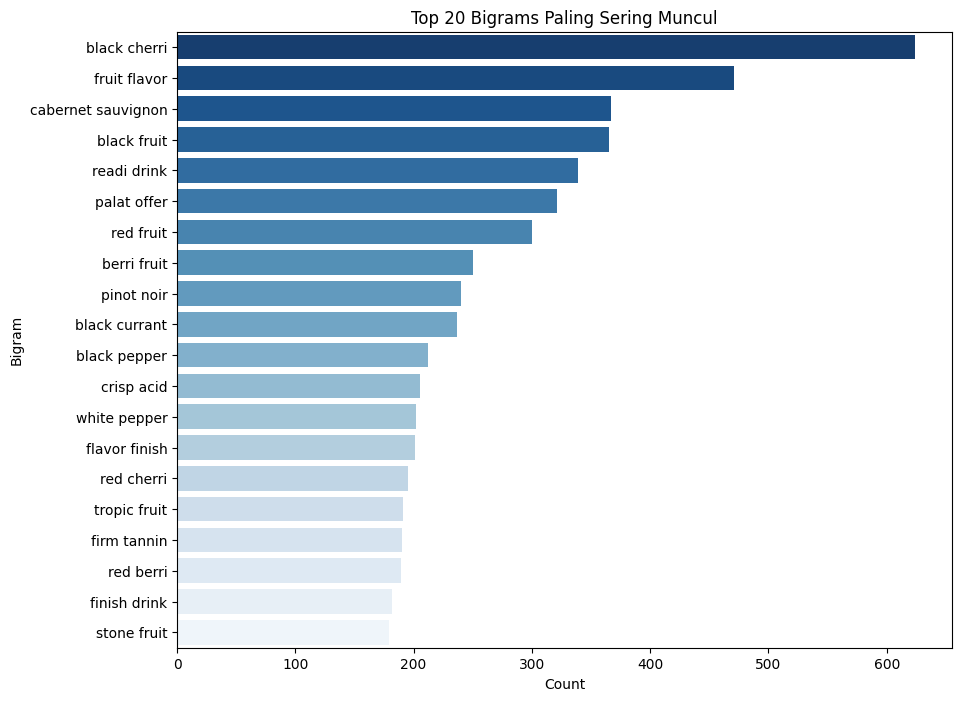

In [ ]:
ngram_vect = CountVectorizer(ngram_range=(2,2), max_features=20)
ngram_matrix = ngram_vect.fit_transform(selected_df['final_text'])

# Dataframe hasil bigram
ngram_df = pd.DataFrame(ngram_matrix.toarray(), columns=ngram_vect.get_feature_names_out())
display(ngram_df.head())

# Visualisasi Top 20 Bigrams
plt.figure(figsize=(10, 8))
sums = ngram_matrix.sum(axis=0)
data_ngram = []
for col, i in ngram_vect.vocabulary_.items():
    data_ngram.append([col, sums[0, i]])

df_ngram = pd.DataFrame(data_ngram, columns=['Bigram', 'Count']).sort_values(by='Count', ascending=False)
sns.barplot(x='Count', y='Bigram', data=df_ngram, palette='Blues_r')
plt.title('Top 20 Bigrams Paling Sering Muncul')
plt.show()

/tmp/ipykernel_6138/87469238.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Bigram', data=top_10_ngram, palette='magma')


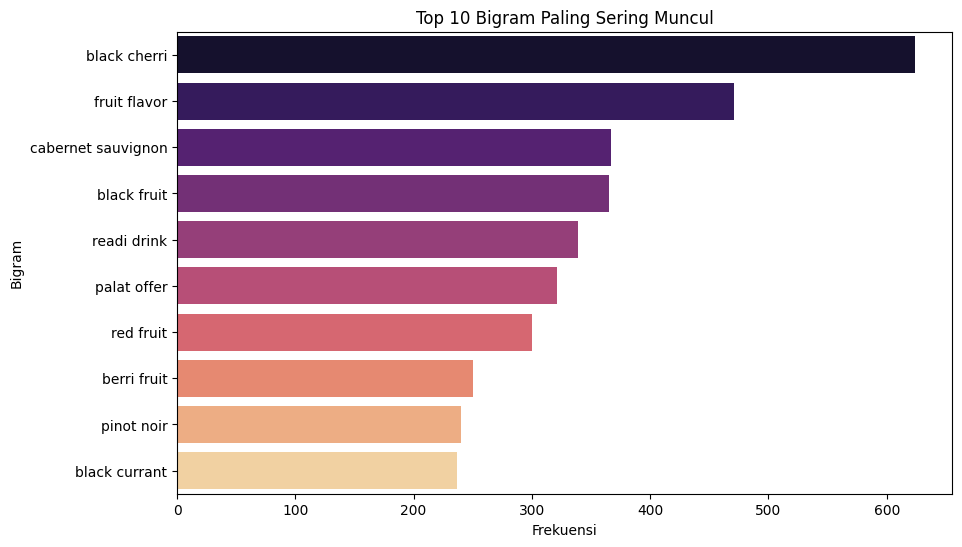

In [ ]:
# Visualisasi Top 10 Bigrams (N-Gram)
plt.figure(figsize=(10, 6))
top_10_ngram = df_ngram.head(10)
sns.barplot(x='Count', y='Bigram', data=top_10_ngram, palette='magma')
plt.title('Top 10 Bigram Paling Sering Muncul')
plt.xlabel('Frekuensi')
plt.ylabel('Bigram')
plt.show()

# 11. Representasi Teks: Bag of Words (BoW)
Mengekstraksi frekuensi kemunculan kata-kata tunggal paling umum dalam dataset.

,acid,aroma,cherri,drink,finish,flavor,fruit,palat,tannin,wine
0,0,0,0,0,0,1,0,0,0,0
1,1,0,0,0,0,1,0,0,0,2
2,0,1,0,0,1,1,1,0,0,0
3,0,0,1,1,0,2,0,0,0,1
4,1,0,1,1,0,1,1,0,0,1


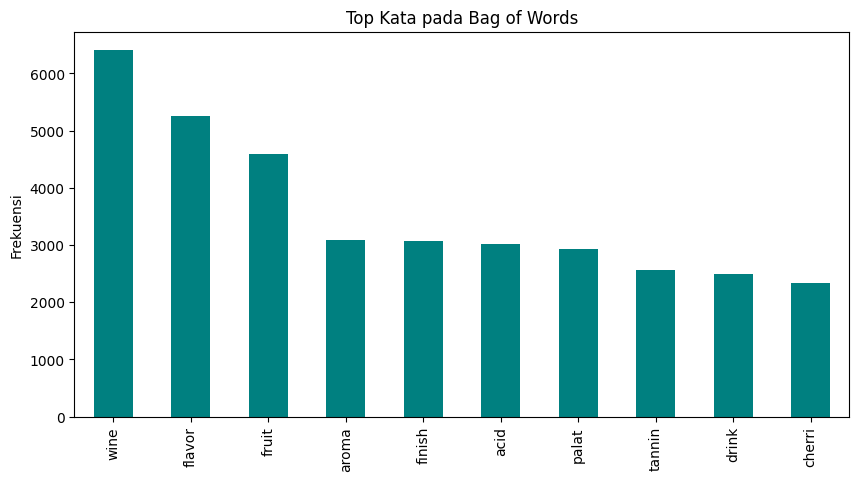

In [ ]:
bow_vect = CountVectorizer(max_features=10)
bow_matrix = bow_vect.fit_transform(selected_df['final_text'])

bow_df = pd.DataFrame(bow_matrix.toarray(), columns=bow_vect.get_feature_names_out())
display(bow_df.head())

# Visualisasi BoW
plt.figure(figsize=(10, 5))
bow_df.sum().sort_values(ascending=False).plot(kind='bar', color='teal')
plt.title('Top Kata pada Bag of Words')
plt.ylabel('Frekuensi')
plt.show()

/tmp/ipykernel_6138/858123951.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bow_counts.values, y=bow_counts.index, palette='magma')


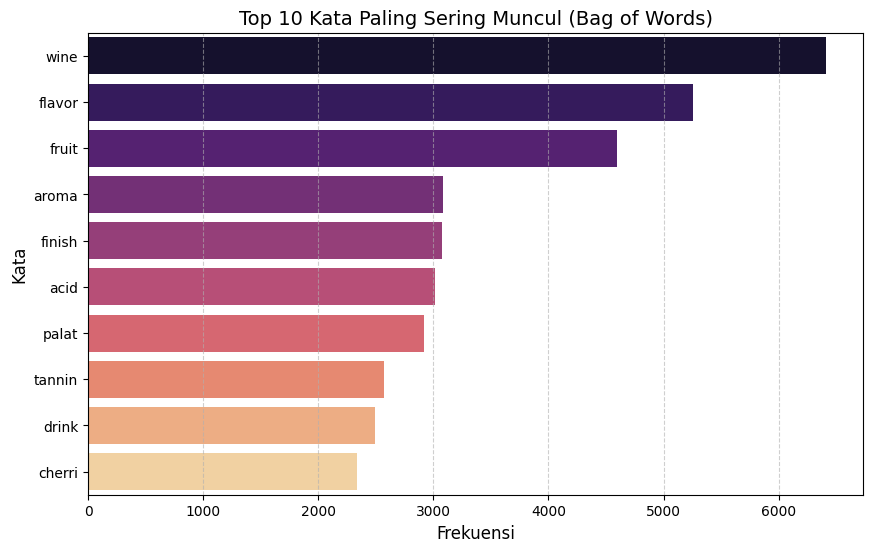

In [ ]:
# Visualisasi Profesional Bag of Words
bow_counts = bow_df.sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=bow_counts.values, y=bow_counts.index, palette='magma')

plt.title("Top 10 Kata Paling Sering Muncul (Bag of Words)", fontsize=14)
plt.xlabel("Frekuensi", fontsize=12)
plt.ylabel("Kata", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

/tmp/ipykernel_6138/2603251513.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_bow.values, y=top_10_bow.index, palette='viridis')


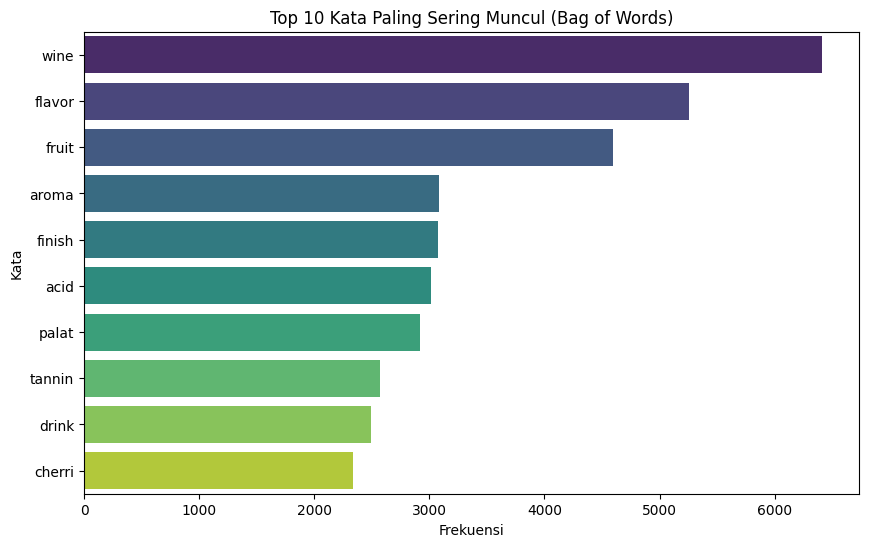

In [ ]:
# Visualisasi Top 10 Words (BoW)
plt.figure(figsize=(10, 6))
top_10_bow = bow_df.sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_10_bow.values, y=top_10_bow.index, palette='viridis')
plt.title('Top 10 Kata Paling Sering Muncul (Bag of Words)')
plt.xlabel('Frekuensi')
plt.ylabel('Kata')
plt.show()

# 12. Pembagian Data (Data Splitting)
Membagi dataset menjadi Data Train dan Data Test untuk validasi performa model.

In [ ]:
# Note: Traditional manual splitting is replaced by the Centralized Stratified Split in Section 14
# for consistency across Classical, Embedding, and Transformer models.
print("Ready for feature transformation and unified experimentation.")

Ready for feature transformation and unified experimentation.


# 13. Definisi Fungsi Evaluasi Terpadu
Membuat fungsi pembantu untuk menghitung metrik performa (Akurasi, F1-Score, dll.) serta menampilkan Confusion Matrix secara otomatis.

In [ ]:
def get_document_vectors(tokens_list, model, size, is_gensim_api=False):
    def get_vec(tokens):
        if is_gensim_api:
            vectors = [model[w] for w in tokens if w in model]
        else:
            vectors = [model.wv[w] for w in tokens if w in model.wv]
        if not vectors:
            return np.zeros(size)
        return np.mean(vectors, axis=0)
    return np.array([get_vec(t) for t in tokens_list])

def run_experiment(X_train, X_test, y_train, y_test, model_obj, name):
    model_obj.fit(X_train, y_train)
    preds = model_obj.predict(X_test)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='weighted', zero_division=0)
    rec = recall_score(y_test, preds, average='weighted', zero_division=0)
    f1 = f1_score(y_test, preds, average='weighted', zero_division=0)
    err = 1 - acc

    # Menampilkan Tabel Lengkap (Accuracy, Error Rate, Precision, Recall, F1)
    print(f"\n[ SUMMARY: {name} ]")
    summary_df = pd.DataFrame({
        'Accuracy': [acc],
        'Error Rate': [err],
        'Precision': [prec],
        'Recall': [rec],
        'F1-score': [f1]
    }, index=[name])
    display(summary_df)

    # Simpan ke RESULTS untuk leaderboard
    RESULTS.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1
    })
    return preds

def plot_individual_cm(y_true, y_pred, name, labels=['High', 'Low', 'Medium']):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='magma', xticklabels=labels, yticklabels=labels)
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

## Update Libraries and Hardware Setup

### Subtask:
Prepare the environment for advanced NLP modeling by importing additional libraries and configuring device settings for deep learning.


In [ ]:
# ==================================================================
# 2.1 ADVANCED VISUALIZATION HELPERS
# ==================================================================

def plot_cm_grid(model_data_list, labels=['High', 'Low', 'Medium']):
    """Plots a grid of confusion matrices for specified models."""
    n = len(model_data_list)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*4))
    axes = axes.flatten()

    for i, (name, y_true, y_pred) in enumerate(model_data_list):
        cm = confusion_matrix(y_true, y_pred, labels=labels)
        sns.heatmap(cm, annot=True, fmt='d', cmap='magma', xticklabels=labels, yticklabels=labels, ax=axes[i])
        axes[i].set_title(f'CM: {name}')

    for j in range(i + 1, len(axes)): axes[j].axis('off')
    plt.tight_layout()
    plt.show()

# 14. Stratifikasi Pembagian Data untuk Embedding
Mengatur pembagian data khusus untuk model berbasis embedding (Word2Vec/GloVe/BERT) dengan metode stratifikasi agar distribusi kelas tetap seimbang.

In [ ]:
# Centralized Stratified Splitting
y = selected_df['quality_label']
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    selected_df['final_text'],
    y,
    test_size=CONFIG['TEST_SIZE'],
    random_state=CONFIG['RANDOM_STATE'],
    stratify=y
)

print(f"Data Split consistent across all experiments: Train {len(X_train_raw)}, Test {len(X_test_raw)}")

Data Split consistent across all experiments: Train 7952, Test 1989


# 15. Eksperimen Model Klasik
Melakukan training dan evaluasi otomatis untuk model Naive Bayes dan Decision Tree menggunakan representasi BoW, TF-IDF, dan N-Gram.

In [ ]:
# 1. CLASSICAL PIPELINE PREPARATION
# Kita hanya menyiapkan vectorizer di sini, pengujian dilakukan di sel individual
vectorizers = {
    'BoW': CountVectorizer(max_features=CONFIG['MAX_FEATURES']),
    'TF-IDF': TfidfVectorizer(max_features=CONFIG['MAX_FEATURES']),
    'N-Gram': CountVectorizer(ngram_range=(2,2), max_features=CONFIG['MAX_FEATURES'])
}

# Kosongkan RESULTS untuk memastikan tidak ada duplikasi dari run sebelumnya
RESULTS = []

print("Classical feature preparation ready. List RESULTS telah dikosongkan.")

Classical feature preparation ready. List RESULTS telah dikosongkan.


# 16. Eksperimen Word Embedding (Word2Vec & GloVe)
Membangun representasi vektor kata menggunakan model Word2Vec (self-trained) dan GloVe (pre-trained), lalu menguji performanya pada classifier.

In [ ]:
# 2. EMBEDDING PIPELINE PREPARATION
train_toks = [t.split() for t in X_train_raw]
test_toks = [t.split() for t in X_test_raw]

# Word2Vec (Self-Trained)
w2v = Word2Vec(sentences=train_toks, vector_size=CONFIG['W2V_SIZE'], window=CONFIG['W2V_WINDOW'], min_count=1, seed=CONFIG['RANDOM_STATE'])
X_tr_w2v = get_document_vectors(train_toks, w2v, CONFIG['W2V_SIZE'])
X_te_w2v = get_document_vectors(test_toks, w2v, CONFIG['W2V_SIZE'])

# GloVe (Pre-Trained)
glove = api.load('glove-wiki-gigaword-100')
X_tr_glove = get_document_vectors(train_toks, glove, 100, is_gensim_api=True)
X_te_glove = get_document_vectors(test_toks, glove, 100, is_gensim_api=True)

print("Embedding features prepared. Siap untuk eksperimen individual.")

[==================================================] 100.0% 128.1/128.1MB downloaded
Embedding features prepared. Siap untuk eksperimen individual.


# 17. Eksperimen Deep Learning (BERT)
Mengekstraksi fitur bahasa yang kompleks menggunakan model Transformer BERT untuk melihat kemampuannya dalam memahami konteks deskripsi wine.

In [ ]:
# 3. BERT PIPELINE PREPARATION
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased').to(DEVICE).eval()

def extract_bert_features(texts):
    feats = []
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), CONFIG['BATCH_SIZE'])):
            batch = texts[i:i+CONFIG['BATCH_SIZE']].tolist()
            inputs = tokenizer(batch, return_tensors='pt', padding=True, truncation=True, max_length=CONFIG['MAX_LEN']).to(DEVICE)
            out = bert_model(**inputs)
            feats.append(out.last_hidden_state.mean(dim=1).cpu().numpy())
    return np.vstack(feats)

SUB = CONFIG['BERT_SUBSET']
X_tr_bert = extract_bert_features(X_train_raw[:SUB])
X_te_bert = extract_bert_features(X_test_raw[:SUB])

# Clean up BERT model memory
del bert_model
torch.cuda.empty_cache()
gc.collect()

print("BERT features extracted. Siap untuk eksperimen individual.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 63/63 [01:35<00:00,  1.52s/it]


BERT features extracted. Siap untuk eksperimen individual.


## 18. EXPERIMENT SECTIONS FOR REPORTING
This section breaks down each of the 12 experiments individually to allow for easy documentation, screenshots, and analysis for the final report.

### EXPERIMENT 1 — Naive Bayes + BoW
Representasi: Bag of Words (Count Vectorizer)

Feature Shape: (7952, 2000)
Preview Transformasi Bag of Words (10 Baris Pertama, Kolom Non-Zero):


,final_text,access,acid,add,addit,aerat,aftertast,age,ageabl,alcohol,allow,almond,almost,along,alongsid,alpin
0,aroma miner spice toast yellow appl lemon pith light enchant palat medium bodi refin demonstr judici use oak lengthi finish show warmth,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,cascina ferrero beauti linear wine cool acid linger aroma chop herb redwood leather tobacco old spice cola linse oil balsam note vertic buoyant wine would pair well fatti food roast suckl pig evolv nice mouth offer polish tannin firm close,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
2,suppl burst ripe purpl fruit real success grape stemmi green charact held restraint purpl plummi fruit flavor come sweet core surround flavor espresso dark chocol stem well balanc firm wine enjoy,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,leather earth wild flower cedar red currant wild cherri aroma lead nose robust wine ripe simpl palat dole rich black cherri vanilla cinnamon clove alongsid big velveti tannin drink soon fresh,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,good solid wine show forthright fruiti aspect variet quit deep color spici earthi cola aroma follow nice ripe plum black cherri palat full bodi give mouthfil sensat firm tannin add welcom grip,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
5,crisp acid save day ripe fruiti young pinot grigio forward flavor pineappl lime kiwi vanilla almost quit sweet acid kick dri cleans finish,0,2,0,0,0,0,0,0,0,0,0,1,0,0,0
6,power exagger style amaron deliv ripe cherri blackberri aroma follow new leather cigar box spice rum cake impart smooth rich suppl feel,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,lift note rose water honeysuckl blossom rise immedi glass remain perfum palat cloth peach fruit floral fragranc pleasantli bitter edg enough fresh stand opul flavor finish medium sweet perfum finish,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,littl extra bottl age help wine soften still seem stop bit short entri firm show oregon herbal charact along tart wild berri light bake spice vagu hint barnyard well tannin begin smooth probabl benefit year cellar,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0
9,small subregion lisboa stylish structur wine firm tannic plenti ripe berri fruit balanc tannin well acid cut rich wine readi drink,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0



[ SUMMARY: NB + BoW ]


,Accuracy,Error Rate,Precision,Recall,F1-score
NB + BoW,0.635495,0.364505,0.640587,0.635495,0.636073



Classification Report:
              precision    recall  f1-score   support

        High       0.59      0.70      0.64       526
         Low       0.51      0.50      0.51       337
      Medium       0.70      0.64      0.67      1126

    accuracy                           0.64      1989
   macro avg       0.60      0.62      0.61      1989
weighted avg       0.64      0.64      0.64      1989



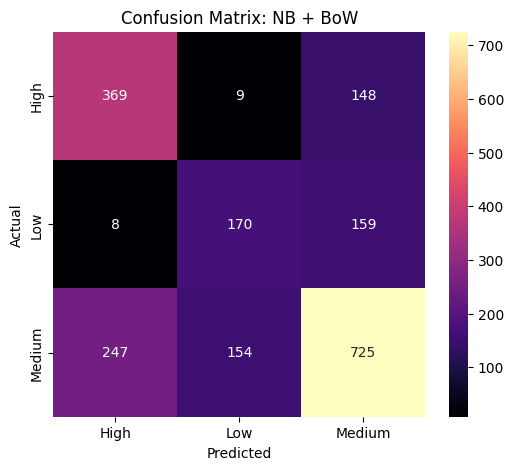

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report

# Memastikan teks tidak terpotong
pd.set_option('display.max_colwidth', None)

# Persiapan Data BoW
vec_bow = CountVectorizer(max_features=CONFIG['MAX_FEATURES'])
X_tr_bow = vec_bow.fit_transform(X_train_raw)
X_te_bow = vec_bow.transform(X_test_raw)

# Membuat Preview Tabel 10 Baris
feat_names = vec_bow.get_feature_names_out()
preview_df = pd.DataFrame(X_tr_bow.toarray()[:100], columns=feat_names)

# Filter: Hanya ambil 15 kolom pertama yang memiliki nilai (tidak nol semua) agar transformasi terlihat
filled_cols = preview_df.columns[(preview_df > 0).any()][:15]

print(f"Feature Shape: {X_tr_bow.shape}")
print("Preview Transformasi Bag of Words (10 Baris Pertama, Kolom Non-Zero):")
display(pd.concat([X_train_raw.head(10).reset_index(drop=True), preview_df[filled_cols].head(10)], axis=1))

# Menjalankan Eksperimen
preds_nb_bow = run_experiment(X_tr_bow, X_te_bow, y_train, y_test, MultinomialNB(), 'NB + BoW')

# Menampilkan Laporan Klasifikasi dan Confusion Matrix
print("\nClassification Report:")
print(classification_report(y_test, preds_nb_bow))
plot_individual_cm(y_test, preds_nb_bow, 'NB + BoW')

### EXPERIMENT 2 — Naive Bayes + TF-IDF

,final_text,access,acid,add,addit,aerat,aftertast,age,ageabl,alcohol,allow,almond,almost,along,alongsid,alpin
0,aroma miner spice toast yellow appl lemon pith light enchant palat medium bodi refin demonstr judici use oak lengthi finish show warmth,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.0
1,cascina ferrero beauti linear wine cool acid linger aroma chop herb redwood leather tobacco old spice cola linse oil balsam note vertic buoyant wine would pair well fatti food roast suckl pig evolv nice mouth offer polish tannin firm close,0.0,0.085873,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.0
2,suppl burst ripe purpl fruit real success grape stemmi green charact held restraint purpl plummi fruit flavor come sweet core surround flavor espresso dark chocol stem well balanc firm wine enjoy,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.0
3,leather earth wild flower cedar red currant wild cherri aroma lead nose robust wine ripe simpl palat dole rich black cherri vanilla cinnamon clove alongsid big velveti tannin drink soon fresh,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.00000,0.000000,0.184257,0.0
4,good solid wine show forthright fruiti aspect variet quit deep color spici earthi cola aroma follow nice ripe plum black cherri palat full bodi give mouthfil sensat firm tannin add welcom grip,0.0,0.000000,0.194278,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.0
5,crisp acid save day ripe fruiti young pinot grigio forward flavor pineappl lime kiwi vanilla almost quit sweet acid kick dri cleans finish,0.0,0.210512,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.21457,0.000000,0.000000,0.0
6,power exagger style amaron deliv ripe cherri blackberri aroma follow new leather cigar box spice rum cake impart smooth rich suppl feel,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.0
7,lift note rose water honeysuckl blossom rise immedi glass remain perfum palat cloth peach fruit floral fragranc pleasantli bitter edg enough fresh stand opul flavor finish medium sweet perfum finish,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.0
8,littl extra bottl age help wine soften still seem stop bit short entri firm show oregon herbal charact along tart wild berri light bake spice vagu hint barnyard well tannin begin smooth probabl benefit year cellar,0.0,0.000000,0.000000,0.0,0.0,0.0,0.121883,0.0,0.0,0.0,0.0,0.00000,0.148789,0.000000,0.0
9,small subregion lisboa stylish structur wine firm tannic plenti ripe berri fruit balanc tannin well acid cut rich wine readi drink,0.0,0.137971,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.0



[ SUMMARY: NB + TF-IDF ]


,Accuracy,Error Rate,Precision,Recall,F1-score
NB + TF-IDF,0.652086,0.347914,0.689695,0.652086,0.602789


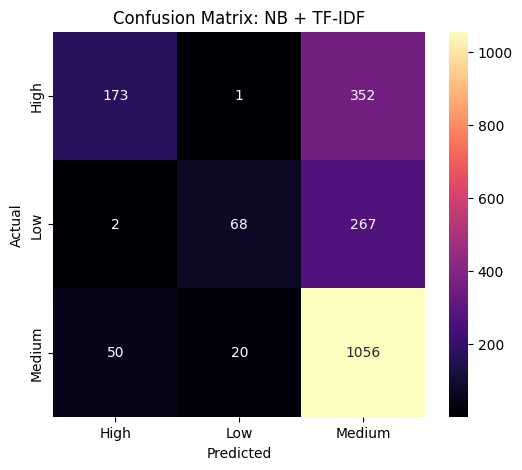

In [ ]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

vec_tfidf = TfidfVectorizer(max_features=CONFIG['MAX_FEATURES'])
X_tr_tfidf = vec_tfidf.fit_transform(X_train_raw)
X_te_tfidf = vec_tfidf.transform(X_test_raw)

# Preview 10 rows with values
feat_names = vec_tfidf.get_feature_names_out()
preview_df = pd.DataFrame(X_tr_tfidf.toarray()[:100], columns=feat_names)
# Ambil kolom yang ada isinya (bukan nol semua)
filled_cols = preview_df.columns[(preview_df > 0).any()][:15]
display(pd.concat([X_train_raw.head(10).reset_index(drop=True), preview_df[filled_cols].head(10)], axis=1))

preds_nb_tfidf = run_experiment(X_tr_tfidf, X_te_tfidf, y_train, y_test, MultinomialNB(), 'NB + TF-IDF')
plot_individual_cm(y_test, preds_nb_tfidf, 'NB + TF-IDF')

### EXPERIMENT 3 — Naive Bayes + N-Gram (Bigram)

,final_text,acid along,acid cut,acid drink,acid fine,acid finish,acid give,acid hint,acid keep,acid lend,acid linger,acid rich,acid round,acid spice,acid tannin,add complex
0,aroma miner spice toast yellow appl lemon pith light enchant palat medium bodi refin demonstr judici use oak lengthi finish show warmth,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,cascina ferrero beauti linear wine cool acid linger aroma chop herb redwood leather tobacco old spice cola linse oil balsam note vertic buoyant wine would pair well fatti food roast suckl pig evolv nice mouth offer polish tannin firm close,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
2,suppl burst ripe purpl fruit real success grape stemmi green charact held restraint purpl plummi fruit flavor come sweet core surround flavor espresso dark chocol stem well balanc firm wine enjoy,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,leather earth wild flower cedar red currant wild cherri aroma lead nose robust wine ripe simpl palat dole rich black cherri vanilla cinnamon clove alongsid big velveti tannin drink soon fresh,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,good solid wine show forthright fruiti aspect variet quit deep color spici earthi cola aroma follow nice ripe plum black cherri palat full bodi give mouthfil sensat firm tannin add welcom grip,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,crisp acid save day ripe fruiti young pinot grigio forward flavor pineappl lime kiwi vanilla almost quit sweet acid kick dri cleans finish,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,power exagger style amaron deliv ripe cherri blackberri aroma follow new leather cigar box spice rum cake impart smooth rich suppl feel,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,lift note rose water honeysuckl blossom rise immedi glass remain perfum palat cloth peach fruit floral fragranc pleasantli bitter edg enough fresh stand opul flavor finish medium sweet perfum finish,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,littl extra bottl age help wine soften still seem stop bit short entri firm show oregon herbal charact along tart wild berri light bake spice vagu hint barnyard well tannin begin smooth probabl benefit year cellar,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,small subregion lisboa stylish structur wine firm tannic plenti ripe berri fruit balanc tannin well acid cut rich wine readi drink,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0



[ SUMMARY: NB + N-Gram ]


,Accuracy,Error Rate,Precision,Recall,F1-score
NB + N-Gram,0.540473,0.459527,0.531399,0.540473,0.534148


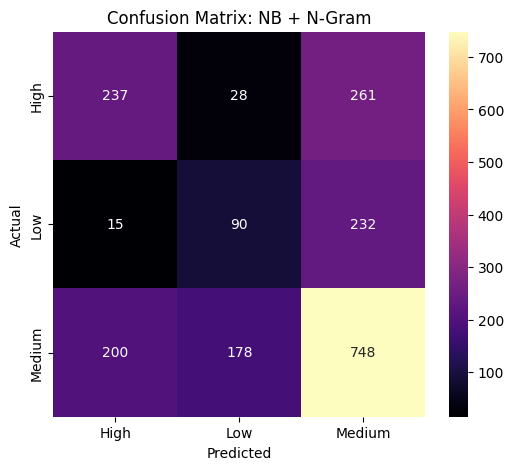

In [ ]:
vec_ngram = CountVectorizer(ngram_range=(2,2), max_features=CONFIG['MAX_FEATURES'])
X_tr_ngram = vec_ngram.fit_transform(X_train_raw)
X_te_ngram = vec_ngram.transform(X_test_raw)

# Preview 10 rows
feat_names = vec_ngram.get_feature_names_out()
preview_df = pd.DataFrame(X_tr_ngram.toarray()[:100], columns=feat_names)
filled_cols = preview_df.columns[(preview_df > 0).any()][:15]
display(pd.concat([X_train_raw.head(10).reset_index(drop=True), preview_df[filled_cols].head(10)], axis=1))

preds_nb_ngram = run_experiment(X_tr_ngram, X_te_ngram, y_train, y_test, MultinomialNB(), 'NB + N-Gram')
plot_individual_cm(y_test, preds_nb_ngram, 'NB + N-Gram')

### EXPERIMENT 4 — Decision Tree + BoW

,final_text,access,acid,add,addit,aerat,aftertast,age,ageabl,alcohol,allow,almond,almost,along,alongsid,alpin
0,aroma miner spice toast yellow appl lemon pith light enchant palat medium bodi refin demonstr judici use oak lengthi finish show warmth,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,cascina ferrero beauti linear wine cool acid linger aroma chop herb redwood leather tobacco old spice cola linse oil balsam note vertic buoyant wine would pair well fatti food roast suckl pig evolv nice mouth offer polish tannin firm close,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
2,suppl burst ripe purpl fruit real success grape stemmi green charact held restraint purpl plummi fruit flavor come sweet core surround flavor espresso dark chocol stem well balanc firm wine enjoy,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,leather earth wild flower cedar red currant wild cherri aroma lead nose robust wine ripe simpl palat dole rich black cherri vanilla cinnamon clove alongsid big velveti tannin drink soon fresh,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,good solid wine show forthright fruiti aspect variet quit deep color spici earthi cola aroma follow nice ripe plum black cherri palat full bodi give mouthfil sensat firm tannin add welcom grip,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
5,crisp acid save day ripe fruiti young pinot grigio forward flavor pineappl lime kiwi vanilla almost quit sweet acid kick dri cleans finish,0,2,0,0,0,0,0,0,0,0,0,1,0,0,0
6,power exagger style amaron deliv ripe cherri blackberri aroma follow new leather cigar box spice rum cake impart smooth rich suppl feel,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,lift note rose water honeysuckl blossom rise immedi glass remain perfum palat cloth peach fruit floral fragranc pleasantli bitter edg enough fresh stand opul flavor finish medium sweet perfum finish,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,littl extra bottl age help wine soften still seem stop bit short entri firm show oregon herbal charact along tart wild berri light bake spice vagu hint barnyard well tannin begin smooth probabl benefit year cellar,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0
9,small subregion lisboa stylish structur wine firm tannic plenti ripe berri fruit balanc tannin well acid cut rich wine readi drink,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0



[ SUMMARY: DT + BoW ]


,Accuracy,Error Rate,Precision,Recall,F1-score
DT + BoW,0.605832,0.394168,0.6016,0.605832,0.564189


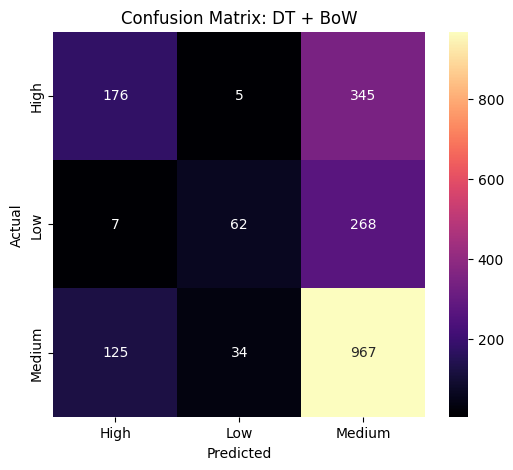

In [ ]:
# DT + BoW Preview (Reuse X_tr_bow from Exp 1)
preview_df = pd.DataFrame(X_tr_bow.toarray()[:100], columns=vec_bow.get_feature_names_out())
filled_cols = preview_df.columns[(preview_df > 0).any()][:15]
display(pd.concat([X_train_raw.head(10).reset_index(drop=True), preview_df[filled_cols].head(10)], axis=1))

preds_dt_bow = run_experiment(X_tr_bow, X_te_bow, y_train, y_test, DecisionTreeClassifier(max_depth=20, random_state=42), 'DT + BoW')
plot_individual_cm(y_test, preds_dt_bow, 'DT + BoW')

### EXPERIMENT 5 — Decision Tree + TF-IDF

,final_text,access,acid,add,addit,aerat,aftertast,age,ageabl,alcohol,allow,almond,almost,along,alongsid,alpin
0,aroma miner spice toast yellow appl lemon pith light enchant palat medium bodi refin demonstr judici use oak lengthi finish show warmth,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.0
1,cascina ferrero beauti linear wine cool acid linger aroma chop herb redwood leather tobacco old spice cola linse oil balsam note vertic buoyant wine would pair well fatti food roast suckl pig evolv nice mouth offer polish tannin firm close,0.0,0.085873,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.0
2,suppl burst ripe purpl fruit real success grape stemmi green charact held restraint purpl plummi fruit flavor come sweet core surround flavor espresso dark chocol stem well balanc firm wine enjoy,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.0
3,leather earth wild flower cedar red currant wild cherri aroma lead nose robust wine ripe simpl palat dole rich black cherri vanilla cinnamon clove alongsid big velveti tannin drink soon fresh,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.00000,0.000000,0.184257,0.0
4,good solid wine show forthright fruiti aspect variet quit deep color spici earthi cola aroma follow nice ripe plum black cherri palat full bodi give mouthfil sensat firm tannin add welcom grip,0.0,0.000000,0.194278,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.0
5,crisp acid save day ripe fruiti young pinot grigio forward flavor pineappl lime kiwi vanilla almost quit sweet acid kick dri cleans finish,0.0,0.210512,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.21457,0.000000,0.000000,0.0
6,power exagger style amaron deliv ripe cherri blackberri aroma follow new leather cigar box spice rum cake impart smooth rich suppl feel,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.0
7,lift note rose water honeysuckl blossom rise immedi glass remain perfum palat cloth peach fruit floral fragranc pleasantli bitter edg enough fresh stand opul flavor finish medium sweet perfum finish,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.0
8,littl extra bottl age help wine soften still seem stop bit short entri firm show oregon herbal charact along tart wild berri light bake spice vagu hint barnyard well tannin begin smooth probabl benefit year cellar,0.0,0.000000,0.000000,0.0,0.0,0.0,0.121883,0.0,0.0,0.0,0.0,0.00000,0.148789,0.000000,0.0
9,small subregion lisboa stylish structur wine firm tannic plenti ripe berri fruit balanc tannin well acid cut rich wine readi drink,0.0,0.137971,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.0



[ SUMMARY: DT + TF-IDF ]


,Accuracy,Error Rate,Precision,Recall,F1-score
DT + TF-IDF,0.595274,0.404726,0.577235,0.595274,0.566192


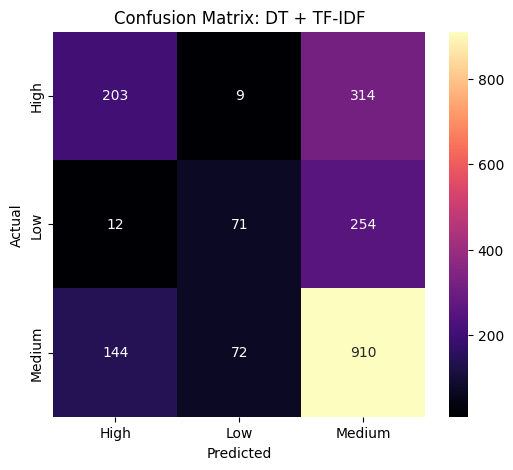

In [ ]:
# Preview DT + TF-IDF
preview_df = pd.DataFrame(X_tr_tfidf.toarray()[:100], columns=vec_tfidf.get_feature_names_out())
filled_cols = preview_df.columns[(preview_df > 0).any()][:15]
display(pd.concat([X_train_raw.head(10).reset_index(drop=True), preview_df[filled_cols].head(10)], axis=1))

preds_dt_tfidf = run_experiment(X_tr_tfidf, X_te_tfidf, y_train, y_test, DecisionTreeClassifier(max_depth=20, random_state=42), 'DT + TF-IDF')
plot_individual_cm(y_test, preds_dt_tfidf, 'DT + TF-IDF')

### EXPERIMENT 6 — Decision Tree + N-Gram

,final_text,acid along,acid cut,acid drink,acid fine,acid finish,acid give,acid hint,acid keep,acid lend,acid linger,acid rich,acid round,acid spice,acid tannin,add complex
0,aroma miner spice toast yellow appl lemon pith light enchant palat medium bodi refin demonstr judici use oak lengthi finish show warmth,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,cascina ferrero beauti linear wine cool acid linger aroma chop herb redwood leather tobacco old spice cola linse oil balsam note vertic buoyant wine would pair well fatti food roast suckl pig evolv nice mouth offer polish tannin firm close,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
2,suppl burst ripe purpl fruit real success grape stemmi green charact held restraint purpl plummi fruit flavor come sweet core surround flavor espresso dark chocol stem well balanc firm wine enjoy,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,leather earth wild flower cedar red currant wild cherri aroma lead nose robust wine ripe simpl palat dole rich black cherri vanilla cinnamon clove alongsid big velveti tannin drink soon fresh,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,good solid wine show forthright fruiti aspect variet quit deep color spici earthi cola aroma follow nice ripe plum black cherri palat full bodi give mouthfil sensat firm tannin add welcom grip,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,crisp acid save day ripe fruiti young pinot grigio forward flavor pineappl lime kiwi vanilla almost quit sweet acid kick dri cleans finish,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,power exagger style amaron deliv ripe cherri blackberri aroma follow new leather cigar box spice rum cake impart smooth rich suppl feel,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,lift note rose water honeysuckl blossom rise immedi glass remain perfum palat cloth peach fruit floral fragranc pleasantli bitter edg enough fresh stand opul flavor finish medium sweet perfum finish,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,littl extra bottl age help wine soften still seem stop bit short entri firm show oregon herbal charact along tart wild berri light bake spice vagu hint barnyard well tannin begin smooth probabl benefit year cellar,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,small subregion lisboa stylish structur wine firm tannic plenti ripe berri fruit balanc tannin well acid cut rich wine readi drink,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0



[ SUMMARY: DT + N-Gram ]


,Accuracy,Error Rate,Precision,Recall,F1-score
DT + N-Gram,0.573655,0.426345,0.550043,0.573655,0.479127


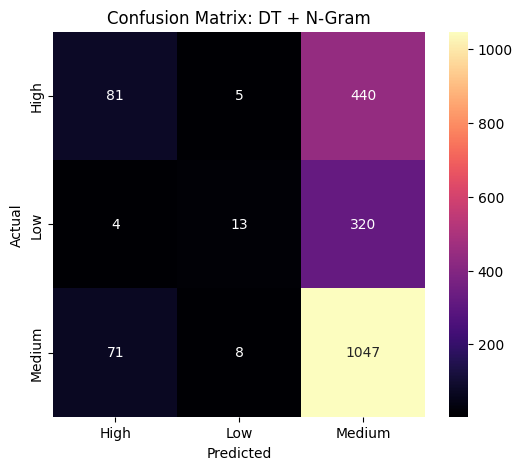

In [ ]:
# Preview DT + N-Gram
preview_df = pd.DataFrame(X_tr_ngram.toarray()[:100], columns=vec_ngram.get_feature_names_out())
filled_cols = preview_df.columns[(preview_df > 0).any()][:15]
display(pd.concat([X_train_raw.head(10).reset_index(drop=True), preview_df[filled_cols].head(10)], axis=1))

preds_dt_ngram = run_experiment(X_tr_ngram, X_te_ngram, y_train, y_test, DecisionTreeClassifier(max_depth=20, random_state=42), 'DT + N-Gram')
plot_individual_cm(y_test, preds_dt_ngram, 'DT + N-Gram')

### EXPERIMENT 7 — Decision Tree + Word2Vec
Representasi: Self-trained Word2Vec Average Vectors

Preview Word2Vec Vectors (First 15 dimensions shown):


,final_text,w2v_0,w2v_1,w2v_2,w2v_3,w2v_4,w2v_5,w2v_6,w2v_7,w2v_8,w2v_9,w2v_10,w2v_11,w2v_12,w2v_13,w2v_14
0,aroma miner spice toast yellow appl lemon pith light enchant palat medium bodi refin demonstr judici use oak lengthi finish show warmth,0.159419,-0.140384,-0.537671,-0.334951,-0.216915,0.505204,0.208064,0.436621,-0.271469,-0.169829,-0.792706,0.264636,0.160529,0.686588,-0.240493
1,cascina ferrero beauti linear wine cool acid linger aroma chop herb redwood leather tobacco old spice cola linse oil balsam note vertic buoyant wine would pair well fatti food roast suckl pig evolv nice mouth offer polish tannin firm close,0.014375,-0.096980,-0.180699,-0.225628,-0.167358,0.276083,0.393870,0.490050,-0.351495,-0.224486,-0.747156,0.248739,0.121929,0.476596,-0.179961
2,suppl burst ripe purpl fruit real success grape stemmi green charact held restraint purpl plummi fruit flavor come sweet core surround flavor espresso dark chocol stem well balanc firm wine enjoy,-0.055441,-0.056882,-0.251412,-0.300327,-0.205092,0.306830,0.424602,0.661000,-0.489077,-0.192082,-0.802944,0.323470,0.071705,0.523140,-0.139052
3,leather earth wild flower cedar red currant wild cherri aroma lead nose robust wine ripe simpl palat dole rich black cherri vanilla cinnamon clove alongsid big velveti tannin drink soon fresh,-0.178426,-0.058151,-0.130157,-0.508694,-0.198715,0.176986,0.624375,0.777662,-0.399291,-0.478069,-1.114553,0.308898,0.142101,0.638807,-0.267067
4,good solid wine show forthright fruiti aspect variet quit deep color spici earthi cola aroma follow nice ripe plum black cherri palat full bodi give mouthfil sensat firm tannin add welcom grip,-0.132018,-0.057672,-0.156080,-0.363204,-0.249720,0.256475,0.496123,0.754831,-0.502057,-0.266837,-0.895255,0.298041,0.031085,0.564266,-0.178767
5,crisp acid save day ripe fruiti young pinot grigio forward flavor pineappl lime kiwi vanilla almost quit sweet acid kick dri cleans finish,0.160775,-0.182001,-0.470473,-0.303182,-0.335042,0.625673,0.165724,0.522650,-0.410934,-0.116811,-0.768537,0.246751,0.151963,0.723863,-0.235781
6,power exagger style amaron deliv ripe cherri blackberri aroma follow new leather cigar box spice rum cake impart smooth rich suppl feel,-0.151267,-0.013346,-0.124184,-0.295985,-0.121893,0.076615,0.547029,0.641151,-0.363931,-0.293655,-0.823115,0.259782,-0.003909,0.450471,-0.189727
7,lift note rose water honeysuckl blossom rise immedi glass remain perfum palat cloth peach fruit floral fragranc pleasantli bitter edg enough fresh stand opul flavor finish medium sweet perfum finish,0.142957,-0.141235,-0.441569,-0.308132,-0.247117,0.497788,0.191243,0.475011,-0.292207,-0.173752,-0.766819,0.247691,0.164065,0.684910,-0.232562
8,littl extra bottl age help wine soften still seem stop bit short entri firm show oregon herbal charact along tart wild berri light bake spice vagu hint barnyard well tannin begin smooth probabl benefit year cellar,0.049950,-0.141246,-0.235658,-0.160810,-0.197098,0.353350,0.474158,0.618619,-0.526837,-0.121363,-0.834656,0.346567,0.108833,0.560033,-0.160259
9,small subregion lisboa stylish structur wine firm tannic plenti ripe berri fruit balanc tannin well acid cut rich wine readi drink,-0.070267,-0.074020,-0.308229,-0.372176,-0.350030,0.520031,0.416864,0.847808,-0.827114,-0.124779,-0.850775,0.416753,0.100423,0.586780,-0.040295



[ SUMMARY: DT + Word2Vec ]


,Accuracy,Error Rate,Precision,Recall,F1-score
DT + Word2Vec,0.474108,0.525892,0.465668,0.474108,0.46951


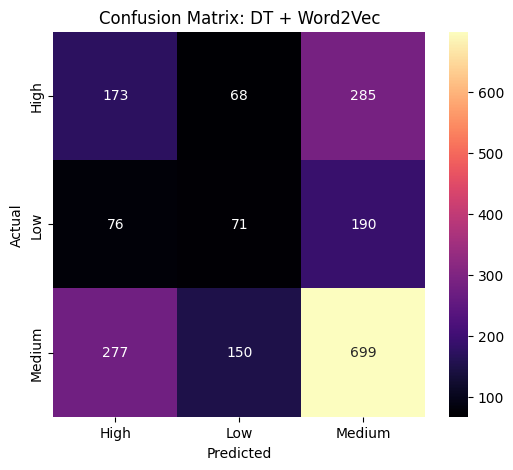

In [ ]:
# Word2Vec Preview Fix: Use correct number of columns
preview_df = pd.DataFrame(X_tr_w2v[:10], columns=[f'w2v_{i}' for i in range(X_tr_w2v.shape[1])])
print('Preview Word2Vec Vectors (First 15 dimensions shown):')
display(pd.concat([X_train_raw.head(10).reset_index(drop=True), preview_df.iloc[:, :15]], axis=1))

preds_dt_w2v = run_experiment(X_tr_w2v, X_te_w2v, y_train, y_test, DecisionTreeClassifier(max_depth=20, random_state=42), 'DT + Word2Vec')
plot_individual_cm(y_test, preds_dt_w2v, 'DT + Word2Vec')

### EXPERIMENT 8 — Naive Bayes + Word2Vec

,final_text,w2v_0,w2v_1,w2v_2,w2v_3,w2v_4,w2v_5,w2v_6,w2v_7,w2v_8,w2v_9,w2v_10,w2v_11,w2v_12,w2v_13,w2v_14
0,aroma miner spice toast yellow appl lemon pith light enchant palat medium bodi refin demonstr judici use oak lengthi finish show warmth,0.159419,-0.140384,-0.537671,-0.334951,-0.216915,0.505204,0.208064,0.436621,-0.271469,-0.169829,-0.792706,0.264636,0.160529,0.686588,-0.240493
1,cascina ferrero beauti linear wine cool acid linger aroma chop herb redwood leather tobacco old spice cola linse oil balsam note vertic buoyant wine would pair well fatti food roast suckl pig evolv nice mouth offer polish tannin firm close,0.014375,-0.096980,-0.180699,-0.225628,-0.167358,0.276083,0.393870,0.490050,-0.351495,-0.224486,-0.747156,0.248739,0.121929,0.476596,-0.179961
2,suppl burst ripe purpl fruit real success grape stemmi green charact held restraint purpl plummi fruit flavor come sweet core surround flavor espresso dark chocol stem well balanc firm wine enjoy,-0.055441,-0.056882,-0.251412,-0.300327,-0.205092,0.306830,0.424602,0.661000,-0.489077,-0.192082,-0.802944,0.323470,0.071705,0.523140,-0.139052
3,leather earth wild flower cedar red currant wild cherri aroma lead nose robust wine ripe simpl palat dole rich black cherri vanilla cinnamon clove alongsid big velveti tannin drink soon fresh,-0.178426,-0.058151,-0.130157,-0.508694,-0.198715,0.176986,0.624375,0.777662,-0.399291,-0.478069,-1.114553,0.308898,0.142101,0.638807,-0.267067
4,good solid wine show forthright fruiti aspect variet quit deep color spici earthi cola aroma follow nice ripe plum black cherri palat full bodi give mouthfil sensat firm tannin add welcom grip,-0.132018,-0.057672,-0.156080,-0.363204,-0.249720,0.256475,0.496123,0.754831,-0.502057,-0.266837,-0.895255,0.298041,0.031085,0.564266,-0.178767
5,crisp acid save day ripe fruiti young pinot grigio forward flavor pineappl lime kiwi vanilla almost quit sweet acid kick dri cleans finish,0.160775,-0.182001,-0.470473,-0.303182,-0.335042,0.625673,0.165724,0.522650,-0.410934,-0.116811,-0.768537,0.246751,0.151963,0.723863,-0.235781
6,power exagger style amaron deliv ripe cherri blackberri aroma follow new leather cigar box spice rum cake impart smooth rich suppl feel,-0.151267,-0.013346,-0.124184,-0.295985,-0.121893,0.076615,0.547029,0.641151,-0.363931,-0.293655,-0.823115,0.259782,-0.003909,0.450471,-0.189727
7,lift note rose water honeysuckl blossom rise immedi glass remain perfum palat cloth peach fruit floral fragranc pleasantli bitter edg enough fresh stand opul flavor finish medium sweet perfum finish,0.142957,-0.141235,-0.441569,-0.308132,-0.247117,0.497788,0.191243,0.475011,-0.292207,-0.173752,-0.766819,0.247691,0.164065,0.684910,-0.232562
8,littl extra bottl age help wine soften still seem stop bit short entri firm show oregon herbal charact along tart wild berri light bake spice vagu hint barnyard well tannin begin smooth probabl benefit year cellar,0.049950,-0.141246,-0.235658,-0.160810,-0.197098,0.353350,0.474158,0.618619,-0.526837,-0.121363,-0.834656,0.346567,0.108833,0.560033,-0.160259
9,small subregion lisboa stylish structur wine firm tannic plenti ripe berri fruit balanc tannin well acid cut rich wine readi drink,-0.070267,-0.074020,-0.308229,-0.372176,-0.350030,0.520031,0.416864,0.847808,-0.827114,-0.124779,-0.850775,0.416753,0.100423,0.586780,-0.040295



[ SUMMARY: NB + Word2Vec ]


,Accuracy,Error Rate,Precision,Recall,F1-score
NB + Word2Vec,0.400704,0.599296,0.512189,0.400704,0.396643


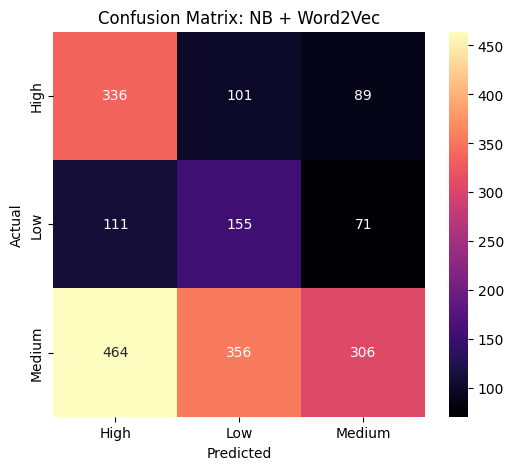

In [ ]:
# Preview NB + Word2Vec
preview_df = pd.DataFrame(X_tr_w2v[:10], columns=[f'w2v_{i}' for i in range(X_tr_w2v.shape[1])])
display(pd.concat([X_train_raw.head(10).reset_index(drop=True), preview_df.iloc[:, :15]], axis=1))

preds_nb_w2v = run_experiment(X_tr_w2v, X_te_w2v, y_train, y_test, GaussianNB(), 'NB + Word2Vec')
plot_individual_cm(y_test, preds_nb_w2v, 'NB + Word2Vec')

### EXPERIMENT 9 — Decision Tree + GloVe
Representasi: Pre-trained GloVe wiki-gigaword-100

,final_text,glove_0,glove_1,glove_2,glove_3,glove_4,glove_5,glove_6,glove_7,glove_8,glove_9,glove_10,glove_11,glove_12,glove_13,glove_14
0,aroma miner spice toast yellow appl lemon pith light enchant palat medium bodi refin demonstr judici use oak lengthi finish show warmth,-0.294383,0.402229,-0.091846,-0.166783,-0.075253,0.017719,0.149656,0.185720,-0.077383,0.156529,-0.046229,-0.064913,-0.028665,0.129331,0.123375
1,cascina ferrero beauti linear wine cool acid linger aroma chop herb redwood leather tobacco old spice cola linse oil balsam note vertic buoyant wine would pair well fatti food roast suckl pig evolv nice mouth offer polish tannin firm close,-0.209308,0.277366,0.044989,-0.123700,-0.014515,-0.002381,0.029992,0.079395,-0.084673,-0.008566,-0.109932,-0.079566,0.077854,0.189005,-0.052157
2,suppl burst ripe purpl fruit real success grape stemmi green charact held restraint purpl plummi fruit flavor come sweet core surround flavor espresso dark chocol stem well balanc firm wine enjoy,-0.220512,0.281366,0.058009,-0.046312,0.094844,0.087431,0.225308,-0.045882,0.074719,-0.025467,-0.255321,-0.129689,0.208437,0.201966,0.012895
3,leather earth wild flower cedar red currant wild cherri aroma lead nose robust wine ripe simpl palat dole rich black cherri vanilla cinnamon clove alongsid big velveti tannin drink soon fresh,-0.380700,0.377268,0.062170,-0.157203,0.070931,0.119221,0.226695,0.059718,-0.021009,-0.186081,-0.279097,-0.035346,0.066761,0.270788,0.124101
4,good solid wine show forthright fruiti aspect variet quit deep color spici earthi cola aroma follow nice ripe plum black cherri palat full bodi give mouthfil sensat firm tannin add welcom grip,-0.230147,0.132441,-0.011348,-0.109621,-0.091996,0.071021,0.063718,0.061004,-0.055981,0.044709,-0.064597,-0.086436,0.142942,0.051117,0.070286
5,crisp acid save day ripe fruiti young pinot grigio forward flavor pineappl lime kiwi vanilla almost quit sweet acid kick dri cleans finish,-0.329530,0.187192,0.104977,-0.264447,-0.022499,0.171549,0.316696,0.100432,-0.240706,0.131888,0.153233,-0.086527,-0.146278,0.121206,0.174955
6,power exagger style amaron deliv ripe cherri blackberri aroma follow new leather cigar box spice rum cake impart smooth rich suppl feel,-0.272871,0.307400,0.185330,-0.187294,-0.021561,0.225467,0.085686,0.083957,0.023105,0.158192,-0.030502,-0.159445,0.067222,0.235364,0.033227
7,lift note rose water honeysuckl blossom rise immedi glass remain perfum palat cloth peach fruit floral fragranc pleasantli bitter edg enough fresh stand opul flavor finish medium sweet perfum finish,-0.259909,0.481832,-0.103236,-0.078874,0.057455,-0.090907,0.144569,0.042733,-0.166852,-0.057962,-0.074880,-0.042876,0.174944,0.102801,0.082565
8,littl extra bottl age help wine soften still seem stop bit short entri firm show oregon herbal charact along tart wild berri light bake spice vagu hint barnyard well tannin begin smooth probabl benefit year cellar,-0.237364,0.199342,0.083139,-0.154487,0.039652,0.102266,0.039741,0.196175,-0.105904,-0.087002,-0.050615,-0.007386,0.111198,0.002492,0.063840
9,small subregion lisboa stylish structur wine firm tannic plenti ripe berri fruit balanc tannin well acid cut rich wine readi drink,-0.482095,0.143325,-0.018462,-0.131741,0.100114,0.175410,0.125401,0.131974,0.050870,0.071961,-0.093541,-0.194291,0.008293,0.147404,-0.180057



[ SUMMARY: DT + GloVe ]


,Accuracy,Error Rate,Precision,Recall,F1-score
DT + GloVe,0.467069,0.532931,0.464303,0.467069,0.465636


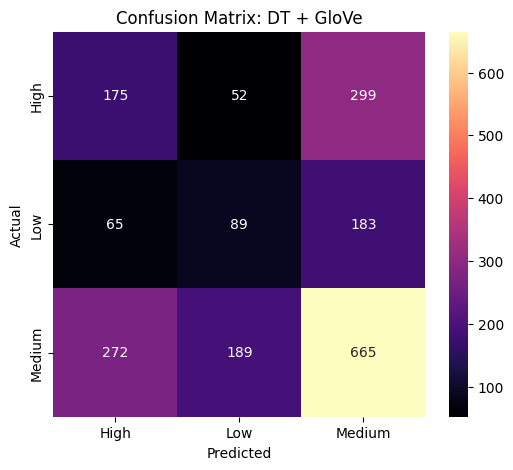

In [ ]:
# Preview DT + GloVe
preview_df = pd.DataFrame(X_tr_glove[:10], columns=[f'glove_{i}' for i in range(X_tr_glove.shape[1])])
display(pd.concat([X_train_raw.head(10).reset_index(drop=True), preview_df.iloc[:, :15]], axis=1))

preds_dt_glove = run_experiment(X_tr_glove, X_te_glove, y_train, y_test, DecisionTreeClassifier(max_depth=20, random_state=42), 'DT + GloVe')
plot_individual_cm(y_test, preds_dt_glove, 'DT + GloVe')

### EXPERIMENT 10 — Naive Bayes + GloVe

,final_text,glove_0,glove_1,glove_2,glove_3,glove_4,glove_5,glove_6,glove_7,glove_8,glove_9,glove_10,glove_11,glove_12,glove_13,glove_14
0,aroma miner spice toast yellow appl lemon pith light enchant palat medium bodi refin demonstr judici use oak lengthi finish show warmth,-0.294383,0.402229,-0.091846,-0.166783,-0.075253,0.017719,0.149656,0.185720,-0.077383,0.156529,-0.046229,-0.064913,-0.028665,0.129331,0.123375
1,cascina ferrero beauti linear wine cool acid linger aroma chop herb redwood leather tobacco old spice cola linse oil balsam note vertic buoyant wine would pair well fatti food roast suckl pig evolv nice mouth offer polish tannin firm close,-0.209308,0.277366,0.044989,-0.123700,-0.014515,-0.002381,0.029992,0.079395,-0.084673,-0.008566,-0.109932,-0.079566,0.077854,0.189005,-0.052157
2,suppl burst ripe purpl fruit real success grape stemmi green charact held restraint purpl plummi fruit flavor come sweet core surround flavor espresso dark chocol stem well balanc firm wine enjoy,-0.220512,0.281366,0.058009,-0.046312,0.094844,0.087431,0.225308,-0.045882,0.074719,-0.025467,-0.255321,-0.129689,0.208437,0.201966,0.012895
3,leather earth wild flower cedar red currant wild cherri aroma lead nose robust wine ripe simpl palat dole rich black cherri vanilla cinnamon clove alongsid big velveti tannin drink soon fresh,-0.380700,0.377268,0.062170,-0.157203,0.070931,0.119221,0.226695,0.059718,-0.021009,-0.186081,-0.279097,-0.035346,0.066761,0.270788,0.124101
4,good solid wine show forthright fruiti aspect variet quit deep color spici earthi cola aroma follow nice ripe plum black cherri palat full bodi give mouthfil sensat firm tannin add welcom grip,-0.230147,0.132441,-0.011348,-0.109621,-0.091996,0.071021,0.063718,0.061004,-0.055981,0.044709,-0.064597,-0.086436,0.142942,0.051117,0.070286
5,crisp acid save day ripe fruiti young pinot grigio forward flavor pineappl lime kiwi vanilla almost quit sweet acid kick dri cleans finish,-0.329530,0.187192,0.104977,-0.264447,-0.022499,0.171549,0.316696,0.100432,-0.240706,0.131888,0.153233,-0.086527,-0.146278,0.121206,0.174955
6,power exagger style amaron deliv ripe cherri blackberri aroma follow new leather cigar box spice rum cake impart smooth rich suppl feel,-0.272871,0.307400,0.185330,-0.187294,-0.021561,0.225467,0.085686,0.083957,0.023105,0.158192,-0.030502,-0.159445,0.067222,0.235364,0.033227
7,lift note rose water honeysuckl blossom rise immedi glass remain perfum palat cloth peach fruit floral fragranc pleasantli bitter edg enough fresh stand opul flavor finish medium sweet perfum finish,-0.259909,0.481832,-0.103236,-0.078874,0.057455,-0.090907,0.144569,0.042733,-0.166852,-0.057962,-0.074880,-0.042876,0.174944,0.102801,0.082565
8,littl extra bottl age help wine soften still seem stop bit short entri firm show oregon herbal charact along tart wild berri light bake spice vagu hint barnyard well tannin begin smooth probabl benefit year cellar,-0.237364,0.199342,0.083139,-0.154487,0.039652,0.102266,0.039741,0.196175,-0.105904,-0.087002,-0.050615,-0.007386,0.111198,0.002492,0.063840
9,small subregion lisboa stylish structur wine firm tannic plenti ripe berri fruit balanc tannin well acid cut rich wine readi drink,-0.482095,0.143325,-0.018462,-0.131741,0.100114,0.175410,0.125401,0.131974,0.050870,0.071961,-0.093541,-0.194291,0.008293,0.147404,-0.180057



[ SUMMARY: NB + GloVe ]


,Accuracy,Error Rate,Precision,Recall,F1-score
NB + GloVe,0.509301,0.490699,0.542848,0.509301,0.513552


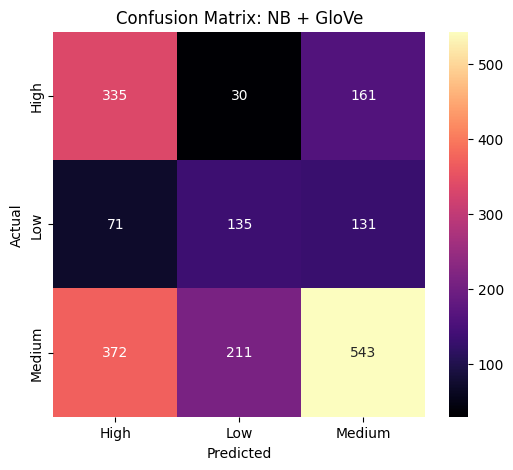

In [ ]:
# Preview NB + GloVe
preview_df = pd.DataFrame(X_tr_glove[:10], columns=[f'glove_{i}' for i in range(X_tr_glove.shape[1])])
display(pd.concat([X_train_raw.head(10).reset_index(drop=True), preview_df.iloc[:, :15]], axis=1))

preds_nb_glove = run_experiment(X_tr_glove, X_te_glove, y_train, y_test, GaussianNB(), 'NB + GloVe')
plot_individual_cm(y_test, preds_nb_glove, 'NB + GloVe')

### EXPERIMENT 11 — Decision Tree + BERT
Representasi: Contextual Embeddings (bert-base-uncased)

Preview BERT Embeddings (First 15 dimensions shown):


,final_text,bert_0,bert_1,bert_2,bert_3,bert_4,bert_5,bert_6,bert_7,bert_8,bert_9,bert_10,bert_11,bert_12,bert_13,bert_14
0,aroma miner spice toast yellow appl lemon pith light enchant palat medium bodi refin demonstr judici use oak lengthi finish show warmth,-0.239706,0.095788,0.323781,-0.030443,0.211850,0.078315,0.157689,-0.011783,0.240427,-0.409575,0.091601,-0.032946,0.400145,0.306524,-0.241430
1,cascina ferrero beauti linear wine cool acid linger aroma chop herb redwood leather tobacco old spice cola linse oil balsam note vertic buoyant wine would pair well fatti food roast suckl pig evolv nice mouth offer polish tannin firm close,0.107660,0.062443,0.438588,0.140489,0.430883,0.029535,-0.107409,0.262313,0.178451,-0.316896,0.088845,0.149599,0.331753,0.180471,-0.043067
2,suppl burst ripe purpl fruit real success grape stemmi green charact held restraint purpl plummi fruit flavor come sweet core surround flavor espresso dark chocol stem well balanc firm wine enjoy,-0.392300,-0.333673,0.234795,0.119170,0.312930,0.038027,-0.058987,0.228640,0.120263,-0.021909,-0.022388,0.167176,0.358757,0.137141,-0.136457
3,leather earth wild flower cedar red currant wild cherri aroma lead nose robust wine ripe simpl palat dole rich black cherri vanilla cinnamon clove alongsid big velveti tannin drink soon fresh,-0.049955,0.064825,0.233240,0.195555,0.354403,0.082504,0.050289,0.336035,0.229994,0.019138,0.073351,0.082722,0.225864,0.233038,-0.213902
4,good solid wine show forthright fruiti aspect variet quit deep color spici earthi cola aroma follow nice ripe plum black cherri palat full bodi give mouthfil sensat firm tannin add welcom grip,-0.259972,-0.217360,0.378140,0.168108,0.272793,0.174942,0.119955,0.366045,0.386100,-0.208433,0.131419,0.206042,0.313458,0.237617,-0.274529
5,crisp acid save day ripe fruiti young pinot grigio forward flavor pineappl lime kiwi vanilla almost quit sweet acid kick dri cleans finish,-0.166667,-0.297347,0.356438,0.190675,0.103231,0.150312,0.182351,0.266663,0.198059,-0.052325,0.145513,0.005819,0.077717,-0.031438,0.023315
6,power exagger style amaron deliv ripe cherri blackberri aroma follow new leather cigar box spice rum cake impart smooth rich suppl feel,-0.116656,-0.019113,0.339146,0.104389,0.283314,-0.020408,0.035308,0.146313,0.387189,-0.234321,0.133330,0.026955,0.334135,0.225865,-0.158430
7,lift note rose water honeysuckl blossom rise immedi glass remain perfum palat cloth peach fruit floral fragranc pleasantli bitter edg enough fresh stand opul flavor finish medium sweet perfum finish,-0.263586,-0.195220,0.376076,0.213060,0.266142,0.131180,0.003435,0.262123,0.145606,-0.167075,-0.029760,-0.235350,0.229900,0.251957,-0.169957
8,littl extra bottl age help wine soften still seem stop bit short entri firm show oregon herbal charact along tart wild berri light bake spice vagu hint barnyard well tannin begin smooth probabl benefit year cellar,0.051638,-0.174451,0.403250,0.168225,0.382535,-0.017302,0.191301,0.155842,0.158100,-0.131570,0.077284,0.119806,0.310693,0.143686,-0.221912
9,small subregion lisboa stylish structur wine firm tannic plenti ripe berri fruit balanc tannin well acid cut rich wine readi drink,-0.373206,-0.106136,0.161661,0.051253,0.392113,-0.023610,-0.093060,0.467493,0.197350,-0.154719,0.054273,-0.040955,0.219060,0.261654,-0.346176



[ SUMMARY: DT + BERT ]


,Accuracy,Error Rate,Precision,Recall,F1-score
DT + BERT,0.472,0.528,0.479322,0.472,0.474955


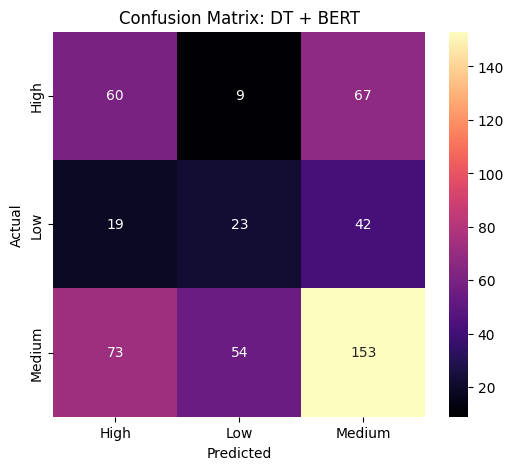

In [ ]:
# BERT Preview Fix: Use correct number of columns
preview_df = pd.DataFrame(X_tr_bert[:10], columns=[f'bert_{i}' for i in range(X_tr_bert.shape[1])])
print('Preview BERT Embeddings (First 15 dimensions shown):')
display(pd.concat([X_train_raw.head(10).reset_index(drop=True), preview_df.iloc[:, :15]], axis=1))

preds_dt_bert = run_experiment(X_tr_bert, X_te_bert, y_train[:SUB], y_test[:SUB], DecisionTreeClassifier(max_depth=20, random_state=42), 'DT + BERT')
plot_individual_cm(y_test[:SUB], preds_dt_bert, 'DT + BERT')

### EXPERIMENT 12 — Naive Bayes + BERT

,final_text,bert_0,bert_1,bert_2,bert_3,bert_4,bert_5,bert_6,bert_7,bert_8,bert_9,bert_10,bert_11,bert_12,bert_13,bert_14
0,aroma miner spice toast yellow appl lemon pith light enchant palat medium bodi refin demonstr judici use oak lengthi finish show warmth,-0.239706,0.095788,0.323781,-0.030443,0.211850,0.078315,0.157689,-0.011783,0.240427,-0.409575,0.091601,-0.032946,0.400145,0.306524,-0.241430
1,cascina ferrero beauti linear wine cool acid linger aroma chop herb redwood leather tobacco old spice cola linse oil balsam note vertic buoyant wine would pair well fatti food roast suckl pig evolv nice mouth offer polish tannin firm close,0.107660,0.062443,0.438588,0.140489,0.430883,0.029535,-0.107409,0.262313,0.178451,-0.316896,0.088845,0.149599,0.331753,0.180471,-0.043067
2,suppl burst ripe purpl fruit real success grape stemmi green charact held restraint purpl plummi fruit flavor come sweet core surround flavor espresso dark chocol stem well balanc firm wine enjoy,-0.392300,-0.333673,0.234795,0.119170,0.312930,0.038027,-0.058987,0.228640,0.120263,-0.021909,-0.022388,0.167176,0.358757,0.137141,-0.136457
3,leather earth wild flower cedar red currant wild cherri aroma lead nose robust wine ripe simpl palat dole rich black cherri vanilla cinnamon clove alongsid big velveti tannin drink soon fresh,-0.049955,0.064825,0.233240,0.195555,0.354403,0.082504,0.050289,0.336035,0.229994,0.019138,0.073351,0.082722,0.225864,0.233038,-0.213902
4,good solid wine show forthright fruiti aspect variet quit deep color spici earthi cola aroma follow nice ripe plum black cherri palat full bodi give mouthfil sensat firm tannin add welcom grip,-0.259972,-0.217360,0.378140,0.168108,0.272793,0.174942,0.119955,0.366045,0.386100,-0.208433,0.131419,0.206042,0.313458,0.237617,-0.274529
5,crisp acid save day ripe fruiti young pinot grigio forward flavor pineappl lime kiwi vanilla almost quit sweet acid kick dri cleans finish,-0.166667,-0.297347,0.356438,0.190675,0.103231,0.150312,0.182351,0.266663,0.198059,-0.052325,0.145513,0.005819,0.077717,-0.031438,0.023315
6,power exagger style amaron deliv ripe cherri blackberri aroma follow new leather cigar box spice rum cake impart smooth rich suppl feel,-0.116656,-0.019113,0.339146,0.104389,0.283314,-0.020408,0.035308,0.146313,0.387189,-0.234321,0.133330,0.026955,0.334135,0.225865,-0.158430
7,lift note rose water honeysuckl blossom rise immedi glass remain perfum palat cloth peach fruit floral fragranc pleasantli bitter edg enough fresh stand opul flavor finish medium sweet perfum finish,-0.263586,-0.195220,0.376076,0.213060,0.266142,0.131180,0.003435,0.262123,0.145606,-0.167075,-0.029760,-0.235350,0.229900,0.251957,-0.169957
8,littl extra bottl age help wine soften still seem stop bit short entri firm show oregon herbal charact along tart wild berri light bake spice vagu hint barnyard well tannin begin smooth probabl benefit year cellar,0.051638,-0.174451,0.403250,0.168225,0.382535,-0.017302,0.191301,0.155842,0.158100,-0.131570,0.077284,0.119806,0.310693,0.143686,-0.221912
9,small subregion lisboa stylish structur wine firm tannic plenti ripe berri fruit balanc tannin well acid cut rich wine readi drink,-0.373206,-0.106136,0.161661,0.051253,0.392113,-0.023610,-0.093060,0.467493,0.197350,-0.154719,0.054273,-0.040955,0.219060,0.261654,-0.346176



[ SUMMARY: NB + BERT ]


,Accuracy,Error Rate,Precision,Recall,F1-score
NB + BERT,0.474,0.526,0.514005,0.474,0.476183


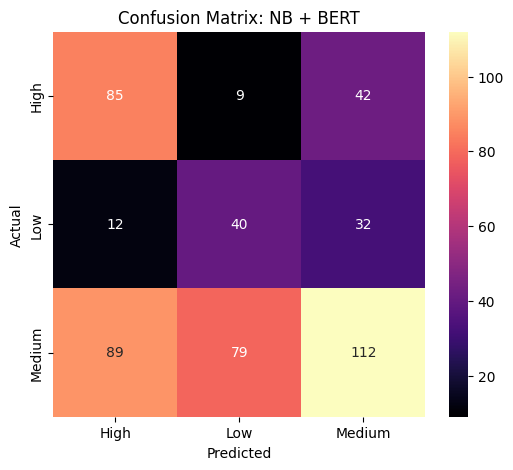

In [ ]:
# Preview NB + BERT
preview_df = pd.DataFrame(X_tr_bert[:10], columns=[f'bert_{i}' for i in range(X_tr_bert.shape[1])])
display(pd.concat([X_train_raw.head(10).reset_index(drop=True), preview_df.iloc[:, :15]], axis=1))

preds_nb_bert = run_experiment(X_tr_bert, X_te_bert, y_train[:SUB], y_test[:SUB], GaussianNB(), 'NB + BERT')
plot_individual_cm(y_test[:SUB], preds_nb_bert, 'NB + BERT')

# FINAL COMPARISON & LEADERBOARD

,Model,Accuracy,Precision,Recall,F1-score
Rank,,,,,
1,NB + BoW,0.635495,0.640587,0.635495,0.636073
2,NB + TF-IDF,0.652086,0.689695,0.652086,0.602789
3,DT + TF-IDF,0.595274,0.577235,0.595274,0.566192
4,DT + BoW,0.605832,0.601600,0.605832,0.564189
5,NB + N-Gram,0.540473,0.531399,0.540473,0.534148
6,NB + GloVe,0.509301,0.542848,0.509301,0.513552
7,DT + N-Gram,0.573655,0.550043,0.573655,0.479127
8,NB + BERT,0.474000,0.514005,0.474000,0.476183
9,DT + BERT,0.472000,0.479322,0.472000,0.474955


/tmp/ipykernel_6138/840089440.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=classical, x='F1-score', y='Model', palette='viridis', ax=ax[0])
/tmp/ipykernel_6138/840089440.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=embeddings, x='F1-score', y='Model', palette='magma', ax=ax[1])


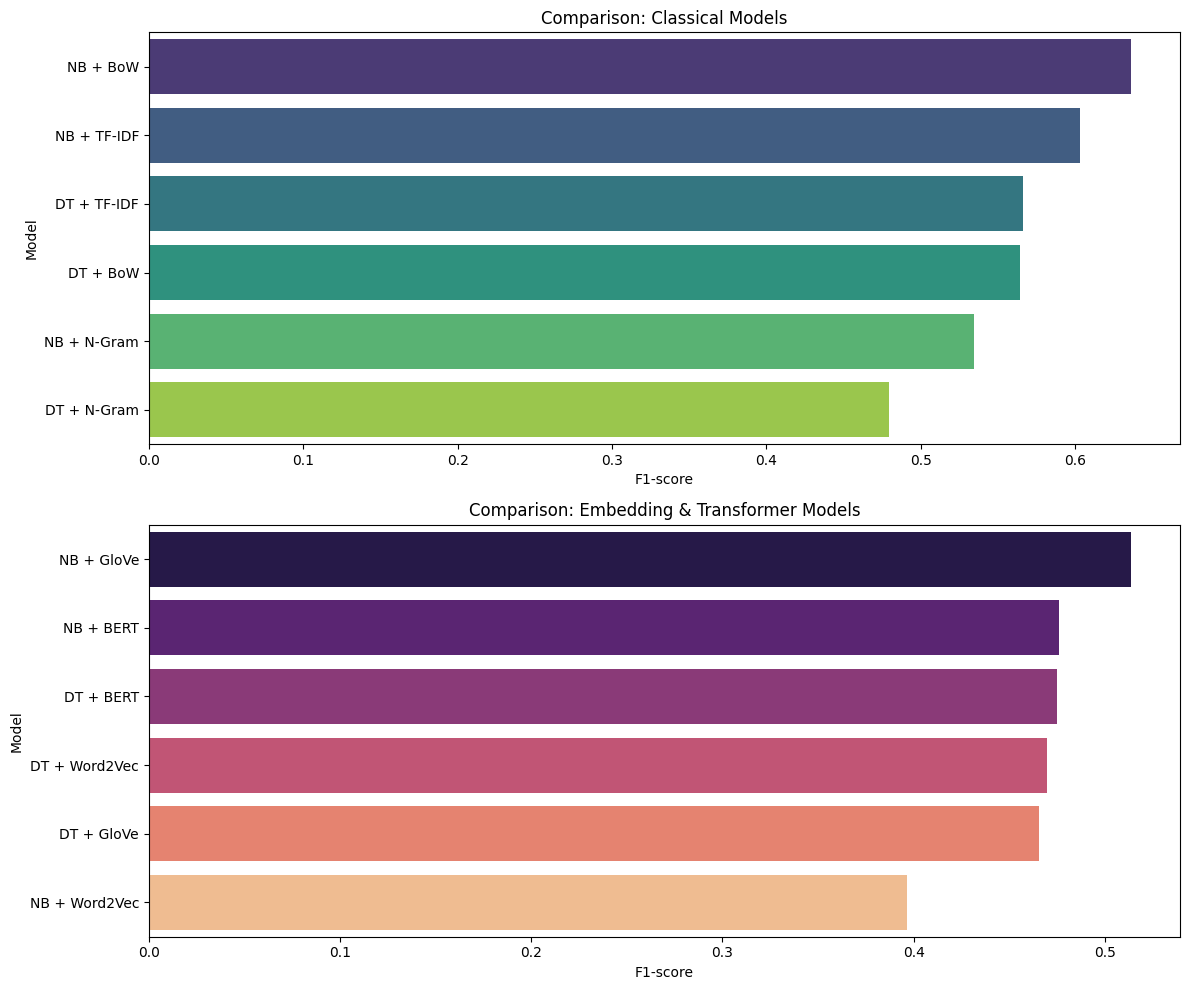

In [ ]:
final_df = pd.DataFrame(RESULTS).sort_values(by='F1-score', ascending=False).reset_index(drop=True)
final_df.index += 1
final_df.index.name = 'Rank'
display(final_df)

# Split visualization for clarity
classical = final_df[~final_df['Model'].str.contains('Word2Vec|GloVe|BERT')]
embeddings = final_df[final_df['Model'].str.contains('Word2Vec|GloVe|BERT')]

fig, ax = plt.subplots(2, 1, figsize=(12, 10))
sns.barplot(data=classical, x='F1-score', y='Model', palette='viridis', ax=ax[0])
ax[0].set_title('Comparison: Classical Models')
sns.barplot(data=embeddings, x='F1-score', y='Model', palette='magma', ax=ax[1])
ax[1].set_title('Comparison: Embedding & Transformer Models')
plt.tight_layout()
plt.show()

# ERROR ANALYSIS — BEST MODEL

In [ ]:
best_model_name = final_df.iloc[0]['Model']
print(f"Analyzing Best Model: {best_model_name}")

# Assuming BERT is often best or we pick index 0 from Results
# For this demonstration, we'll use the results from the top-ranked model.
# Let's create a misclassification table for the winner (using BoW as example if it won)
if 'BoW' in best_model_name:
    y_true, y_pred, texts = y_test, preds_nb_bow, X_test_raw
elif 'TF-IDF' in best_model_name:
    y_true, y_pred, texts = y_test, preds_nb_tfidf, X_test_raw
else:
    # Default to the first 500 for BERT/Subset consistency
    y_true, y_pred, texts = y_test[:SUB], preds_nb_bert, X_test_raw[:SUB]

error_mask = y_true != y_pred
errors_df = pd.DataFrame({
    'Text': texts[error_mask],
    'Actual': y_true[error_mask],
    'Predicted': y_pred[error_mask]
})

print(f"Total Errors: {len(errors_df)}")
print(f"Accuracy: {final_df.iloc[0]['Accuracy']*100:.2f}%")
print(f"Error Rate: {(1-final_df.iloc[0]['Accuracy'])*100:.2f}%")

display(errors_df.head(10))

Analyzing Best Model: NB + BoW
Total Errors: 725
Accuracy: 63.55%
Error Rate: 36.45%


,Text,Actual,Predicted
1107,grapefruit grit show nose narrow palat hint spritz deliv short green melon flavor turn slightli bitter prior pepperytast finish,Medium,Low
5506,made cabernet sauvignon malbec petit verdot stilltight express raspberri cassi veer graphit cedar earthi back palat shine rutherford classic dusti wine develop bottl glass let open,Medium,High
6692,pruney bake somewhat sour blend cabernet sauvignon merlot present overli ripe,Low,Medium
9451,high acid mark vibrant wine one kendalljackson coolest coastal vineyard crisp lend vibrant tension intens flavor meyer lemon orang blossom miner oak add softer spici note feel raci nervi delici way,High,Medium
9338,oak age wine offer black currant stalki tannin juici fruiti ripe charact reflect vintag aftertast acid fresh alway fruiti drink,Low,Medium
5017,soft round raspberri flavor fine full feel tannic structur vintag fit sumptuou cushion textur,Medium,High
7593,stalki aroma suggest anim hide roast fruit wine rubberi firm leatheri feel plum berri raisin darkfruit flavor finish feel earthi tast like stew black fruit prune drink sooner rather later,Medium,Low
9660,white version popular portugues brand soft ripe warmli fruiti flavor fresh appl green plum lace lime juic,Medium,Low
452,subdu ripe yellow pear meet yeasti almost soylik savori headon creat palat full interest wine convey weight concentr bit alcohol heat carri pepperi panach love get better,High,Medium
8532,fragrant fruiti bright crisp clean wine that total readi drink live cool feel like nearbi ocean breez finish light acid,Medium,Low


# 19. Visualisasi Perbandingan Akhir
Menampilkan grafik batang komprehensif yang membandingkan F1-Score dari seluruh 12 kombinasi pipeline yang telah diuji.

In [ ]:
def display_leaderboard():
    """Menampilkan tabel hasil eksperimen yang sudah diurutkan berdasarkan F1-score."""
    if not RESULTS:
        print("Belum ada hasil eksperimen untuk ditampilkan.")
        return

    leaderboard_df = pd.DataFrame(RESULTS).sort_values(by='F1-score', ascending=False).reset_index(drop=True)
    leaderboard_df.index += 1
    leaderboard_df.index.name = 'Rank'

    print("=== MODEL PERFORMANCE LEADERBOARD ===")
    display(leaderboard_df)

display_leaderboard()

=== MODEL PERFORMANCE LEADERBOARD ===


,Model,Accuracy,Precision,Recall,F1-score
Rank,,,,,
1,NB + BoW,0.635495,0.640587,0.635495,0.636073
2,NB + TF-IDF,0.652086,0.689695,0.652086,0.602789
3,DT + TF-IDF,0.595274,0.577235,0.595274,0.566192
4,DT + BoW,0.605832,0.601600,0.605832,0.564189
5,NB + N-Gram,0.540473,0.531399,0.540473,0.534148
6,NB + GloVe,0.509301,0.542848,0.509301,0.513552
7,DT + N-Gram,0.573655,0.550043,0.573655,0.479127
8,NB + BERT,0.474000,0.514005,0.474000,0.476183
9,DT + BERT,0.472000,0.479322,0.472000,0.474955
